# 🎬 Netflix Content Analytics & Business Intelligence Project

### Author
Daniyal

### Project Type
End-to-End Data Analytics Project

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- SQL (Later)
- Power BI (Later)

### Dataset
Netflix Movies and TV Shows Dataset (Kaggle)

---

# 1. Executive Overview

Netflix has become one of the world's largest streaming platforms, offering thousands of movies and TV shows across multiple countries and genres.

This project performs a complete end-to-end analysis of Netflix's content library using Python. The analysis focuses on data quality, exploratory data analysis (EDA), statistical analysis, and business intelligence to uncover meaningful insights that can support strategic decision-making.

# 2. Business Problem

Netflix continuously adds new content from different countries, directors, and genres.

However, without proper analysis, it is difficult to understand:

- Which country contributes the most content?
- Does Netflix focus more on Movies or TV Shows?
- Which genres dominate the platform?
- How has Netflix expanded over the years?
- Which audience ratings are most common?

This project aims to answer these business questions using data-driven analysis.


# 3. Project Objectives

The main objectives of this project are:

- Understand the Netflix dataset
- Assess data quality
- Clean missing and inconsistent data
- Engineer meaningful features
- Perform exploratory data analysis
- Generate professional visualizations
- Extract business insights
- Provide business recommendations

# 4. Dataset Information

**Dataset Name:** Netflix Movies and TV Shows

**Source:** Kaggle

**File Format:** CSV

**Description:**

The dataset contains information about Netflix Movies and TV Shows, including titles, directors, cast members, countries, release years, ratings, durations, genres, and dates when content was added to Netflix.

# 5. Import Libraries

In [305]:
# ======================================================
# Import Required Libraries
# ======================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


# 6. Load Dataset

In [306]:
# ======================================================
# Load Dataset
# ======================================================

df = pd.read_csv("../data/raw/netflix_titles.csv")

# Create Backup Copy
netflix = df.copy()

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


# 7. Initial Data Inspection

In [307]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [308]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [309]:
df.shape

(8807, 12)

In [310]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [311]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [312]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# 8. Data Quality Assessment

Missing Values

In [313]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

Missing Value Percentage

In [314]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


## 9.1 Duplicate Records

In [315]:
df.duplicated().sum()

np.int64(0)

## Data Types

In [316]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## Unique Values


In [317]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values.sort_values("Unique Values", ascending=False)

,Unique Values
show_id,8807
title,8807
description,8775
cast,7692
director,4528
date_added,1767
country,748
listed_in,514
duration,220
release_year,74


## Memory Usage

In [318]:
df.memory_usage(deep=True)

Index               132
show_id          474471
type             480930
title            599158
director         488185
cast            1422387
country          517757
date_added       561028
release_year      70456
rating           470514
duration         493486
listed_in        725748
description     2065368
dtype: int64

## Dataset Summary

In [319]:
audit = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

audit

,Data Type,Missing Values,Unique Values
show_id,str,0,8807
type,str,0,2
title,str,0,8807
director,str,2634,4528
cast,str,825,7692
country,str,831,748
date_added,str,10,1767
release_year,int64,0,74
rating,str,4,17
duration,str,3,220


## Initial Findings


### Observation

- The dataset contains multiple missing values in important columns such as **director**, **cast**, **country**, **date_added**, and **rating**.
- No duplicate records were identified in the original dataset.
- The dataset structure is consistent and ready for preprocessing.

### Business Insight

Missing values can affect the quality of analysis and business decisions. Cleaning the dataset is essential before performing exploratory analysis.

### Recommendation

The next step is to clean the dataset by handling missing values, removing duplicates, fixing data types, and preparing it for feature engineering.

## 9.2 Missing Value Assessment

In [320]:
df_clean = df.copy()

In [321]:
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

Rows: 8807
Columns: 12


In [322]:
df_clean.duplicated().sum()

np.int64(0)

In [323]:
df_clean.drop_duplicates(inplace=True)

In [324]:
df_clean.duplicated().sum()

np.int64(0)

In [325]:
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

Rows: 8807
Columns: 12


### Observation

- Duplicate records were checked and removed from the dataset.
- The dataset now contains only unique records, ensuring more reliable analysis.

### Business Insight

Duplicate records can lead to incorrect statistics and misleading business insights. Removing them improves data quality.

### Recommendation

Always remove duplicate records before starting exploratory data analysis to maintain data integrity.

In [326]:
df_clean.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [327]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


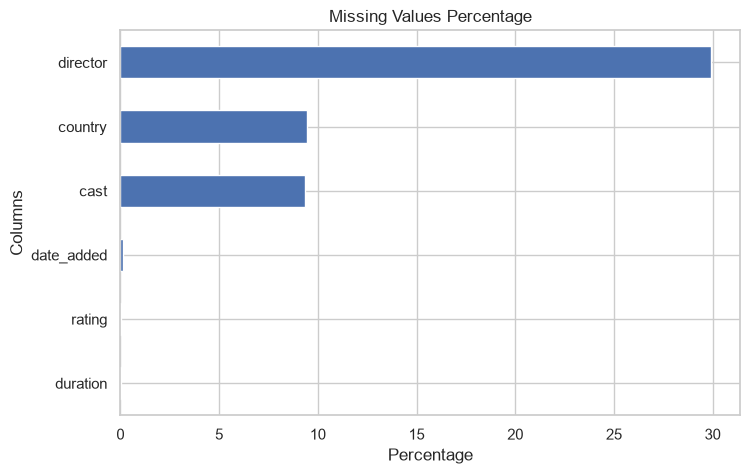

In [328]:
import matplotlib.pyplot as plt

missing.sort_values("Percentage").plot(
    kind="barh",
    y="Percentage",
    figsize=(8, 5),
    legend=False
)

plt.title("Missing Values Percentage")
plt.xlabel("Percentage")
plt.ylabel("Columns")
plt.show()

## Observation

- The `director` column has the highest missing values (29.91%), indicating that director information is unavailable for a significant portion of the content.
- The `country` (9.44%) and `cast` (9.37%) columns also contain noticeable missing values.
- The `date_added`, `rating`, and `duration` columns have very few missing values (less than 1%).
- Overall, the dataset is of good quality, with missing values concentrated in only a few columns.

## Business Insight

Most missing values occur in descriptive metadata rather than core content information. This suggests that the dataset is suitable for analysis after applying appropriate cleaning strategies.

## Recommendation

Instead of dropping all rows with missing values, each column should be handled using a suitable strategy to preserve as much information as possible.

## 9.3 Handle Missing Date Added

In [329]:
df_clean = df_clean.dropna(subset=["date_added"])

In [330]:
df_clean["date_added"].isnull().sum()

np.int64(0)

In [331]:
df_clean[df_clean["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


## 9.4 Handle Missing Ratings

In [332]:
df_clean["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [333]:
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].mode()[0])

In [334]:
df_clean["rating"].isnull().sum()

np.int64(0)

### Observation

- The `rating` column contained only 4 missing values (0.05%).
- Missing values were replaced using the most frequently occurring rating (Mode).
- No records were removed during this step.

### Business Insight

Since the percentage of missing values was extremely low, replacing them with the most common category preserves the dataset without significantly affecting the analysis.

### Recommendation

For categorical variables with a very small percentage of missing values, Mode imputation is an effective and practical approach.

## 9.5 Handle Missing Country

In [335]:
df_clean["country"].isnull().sum()

np.int64(830)

In [336]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [337]:
df_clean["country"].isnull().sum()

np.int64(0)

In [338]:
df_clean["country"].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

### Observation

- The `country` column originally contained 831 missing values.
- After removing records with missing `date_added`, the number of missing country values became 830.
- Missing values were replaced with **"Unknown"** instead of removing the records.
- The United States is the largest content-producing country in the dataset, followed by India and the United Kingdom.

### Business Insight

Country is an important feature for regional content analysis. Replacing missing values with **"Unknown"** preserves valuable records while keeping the dataset suitable for geographical analysis.

### Recommendation

Missing categorical values should be replaced with a meaningful placeholder rather than deleting records. This approach minimizes information loss and improves the reliability of business insights.

## 9.6 Handle Missing Director

In [339]:
df_clean["director"].isnull().sum()

np.int64(2624)

In [340]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

In [341]:
df_clean["director"].isnull().sum()

np.int64(0)

### Observation

- The `director` column initially contained **2,634 missing values**, representing approximately **29.91%** of the dataset.
- Missing values were replaced with **"Unknown"** instead of removing the records.
- All missing values have been successfully handled, and the column is now complete.

### Business Insight

The `director` column is important for analyzing top directors and content trends. Removing nearly 30% of the dataset would result in significant information loss. Replacing missing values with **"Unknown"** preserves the dataset while clearly indicating unavailable information.

### Recommendation

For categorical columns with a high percentage of missing values, replacing missing entries with a meaningful placeholder such as **"Unknown"** is preferable to deleting records. This approach maintains data integrity and supports more comprehensive business analysis.

## 9.7 Handle Missing Cast

In [342]:
df_clean["cast"].isnull().sum()

np.int64(825)

In [343]:
df_clean["cast"] = df_clean["cast"].fillna("Unknown")

In [344]:
df_clean["cast"].isnull().sum()

np.int64(0)

### Observation

- The `cast` column contained missing values for several titles.
- Missing values were replaced with **"Unknown"** to preserve all records.
- The column is now complete and ready for actor-based analysis.

### Business Insight

Cast information is useful for identifying popular actors and analyzing collaborations. Deleting these records would reduce the available content for analysis, while replacing them with **"Unknown"** maintains dataset completeness.

### Recommendation

For categorical columns with a moderate percentage of missing values, replacing null values with **"Unknown"** is an effective strategy that preserves valuable business information.

## 9.8 Handle Missing Duration

In [345]:
df_clean["duration"].isnull().sum()

np.int64(3)

In [346]:
df_clean = df_clean.dropna(subset=["duration"])

In [347]:
df_clean["duration"].isnull().sum()

np.int64(0)

### Observation

- The `duration` column contained only 3 missing values.
- Since the number of missing records was extremely small, these rows were removed from the dataset.
- This ensured that duration-based analysis remains accurate and reliable.

### Business Insight

Duration is a critical attribute for analyzing movie lengths and TV show seasons. Filling missing values with artificial data could introduce bias into the analysis.

### Recommendation

When a numerical or essential analytical column contains only a very small number of missing values, removing those records is often the most reliable approach.

## 9.9 Date Feature Engineering

In [348]:
# Remove whitespace only when the column contains string values
if not pd.api.types.is_datetime64_any_dtype(df_clean["date_added"]):
    df_clean["date_added"] = df_clean["date_added"].str.strip()

# Convert to datetime
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    format="mixed",
    errors="coerce"
)

df_clean["date_added"].dtype

dtype('<M8[us]')

In [349]:
df_clean["date_added"].dtype

dtype('<M8[us]')

### Observation

- The `date_added` column was converted from text (object) to datetime format.
- This enables time-based analysis such as yearly, monthly, and seasonal trends.

### Business Insight

Converting dates into datetime format allows Netflix to analyze content addition patterns over time and identify seasonal content strategies.

### Recommendation

Date columns should always be converted into datetime format before performing temporal analysis.

In [350]:
df_clean["year_added"] = df_clean["date_added"].dt.year

In [351]:
# Calculate content age at the time of catalog addition
df_clean["content_age"] = (
    df_clean["year_added"] - df_clean["release_year"]
)

# Treat negative content age values as invalid timing inconsistencies
df_clean.loc[
    df_clean["content_age"] < 0,
    "content_age"
] = np.nan

In [352]:
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

In [353]:
df_clean["day_added"] = df_clean["date_added"].dt.day_name()

In [354]:
df_clean[["date_added", "year_added", "month_added", "day_added"]].head()

,date_added,year_added,month_added,day_added
0,2021-09-25,2021,September,Saturday
1,2021-09-24,2021,September,Friday
2,2021-09-24,2021,September,Friday
3,2021-09-24,2021,September,Friday
4,2021-09-24,2021,September,Friday


### Observation

- The `date_added` column was successfully converted into datetime format.
- Three new features (`year_added`, `month_added`, and `day_added`) were extracted from the date.
- These new features will enable time-based analysis, such as identifying yearly growth, monthly content additions, and weekday publishing trends.

### Business Insight

Time-based features help Netflix understand when content is added to the platform. This information can be used to identify seasonal trends, optimize release schedules, and improve content planning.

### Recommendation

Always extract useful components from date columns instead of analyzing raw dates directly. Feature engineering improves analytical capabilities and supports better business decision-making.

## 9.10 Duration Feature Engineering

In [355]:
df_clean["duration"].head()

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
Name: duration, dtype: str

In [356]:
df_clean[["duration_value", "duration_unit"]] = df_clean["duration"].str.extract(r"(\d+)\s(.+)")

In [357]:
df_clean["duration_value"] = df_clean["duration_value"].astype(int)

In [358]:
df_clean[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons
5,1 Season,1,Season
6,91 min,91,min
7,125 min,125,min
8,9 Seasons,9,Seasons
9,104 min,104,min


### Observation

- The `duration` column was successfully split into two separate features:
  - `duration_value` (numeric)
  - `duration_unit` (text)
- Movies are represented in minutes (`min`), while TV Shows are represented in seasons (`Season`/`Seasons`).
- The new structure makes the dataset suitable for numerical analysis and comparisons.

### Business Insight

Separating duration into numeric values and units allows Netflix to analyze movie lengths and TV show seasons independently. This enables more accurate reporting and trend analysis.

### Recommendation

Text-based numerical fields should always be converted into structured features before analysis. This improves data quality, simplifies calculations, and supports advanced analytics.

# 10. Exploratory Data Analysis (EDA)

## 10.1 Movies vs TV Shows

In [359]:
df_clean["type"].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

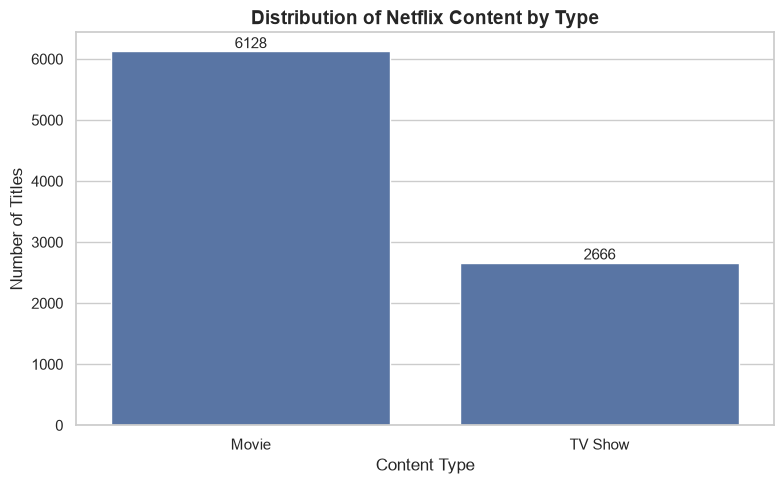

In [360]:
type_counts = df_clean["type"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

for i, value in enumerate(type_counts.values):
    ax.text(i, value + 50, str(value), ha="center", fontsize=11)

plt.title("Distribution of Netflix Content by Type", fontsize=14, fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

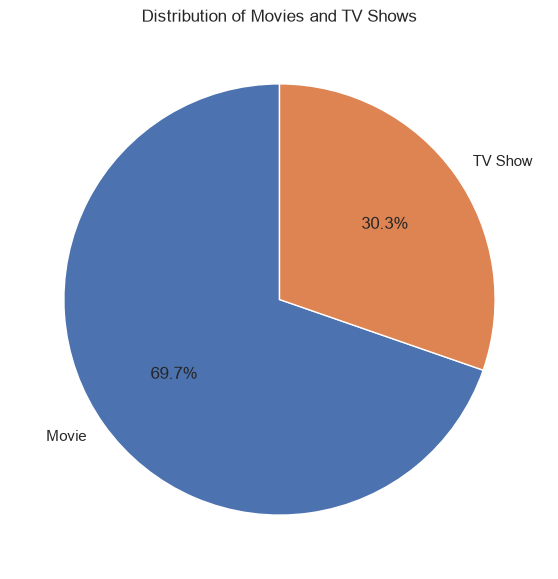

In [361]:
plt.figure(figsize=(7, 7))

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Movies and TV Shows")

plt.show()

### Observation

- The Netflix dataset contains **6,128 Movies** and **2,666 TV Shows**.
- Movies account for approximately **69.7%** of the total content library, while TV Shows represent **30.3%**.
- This indicates that Movies significantly outnumber TV Shows on the platform.

### Business Insight

Netflix's content library is primarily movie-focused. Movies generally require lower long-term production commitments compared to multi-season TV Shows, allowing Netflix to expand its catalog more rapidly and cater to a broader audience.

### Recommendation

Netflix should continue investing in high-quality Movies while increasing production and acquisition of successful TV Shows. Popular TV Shows often improve long-term user engagement and encourage subscription retention.

## 10.2 Content Added Over the Years

In [362]:
yearly_content = df_clean["year_added"].value_counts().sort_index()

yearly_content

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

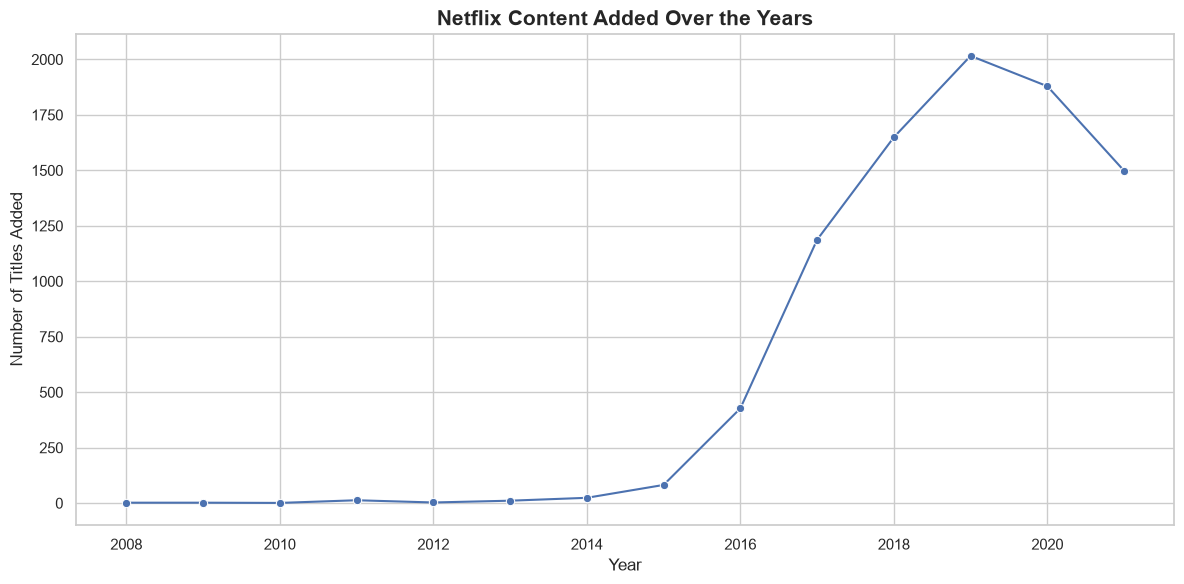

In [363]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=yearly_content.index,
    y=yearly_content.values,
    marker="o"
)

plt.title("Netflix Content Added Over the Years", fontsize=15, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

- Netflix started adding content to the platform in **2008**.
- Content additions remained relatively low between **2008 and 2015**.
- A significant increase in content additions began in **2016**.
- The highest number of titles (**2,016**) was added in **2019**, making it the most active year in the dataset.
- Content additions remained high in **2020 (1,879 titles)** but declined to **1,498 titles** in **2021**.

### Key Finding

Netflix experienced rapid content expansion between **2016 and 2020**, with **2019** being the peak year for content additions.

### Business Insight

The sharp growth between 2016 and 2020 suggests that Netflix aggressively invested in expanding its content library to attract new subscribers and strengthen its competitive position in the streaming market.

The decline in 2021 may indicate a strategic shift toward prioritizing content quality over quantity or external factors affecting content production and acquisition.

### Recommendation

Netflix should continue balancing content quantity with quality. Instead of focusing only on increasing the number of titles, investing in high-performing original content and region-specific productions can improve user engagement and long-term subscriber retention.

## 10.3 Top 10 Content Producing Countries

In [364]:
country_counts = (
    df_clean["country"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

country_counts

country
United States     3680
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

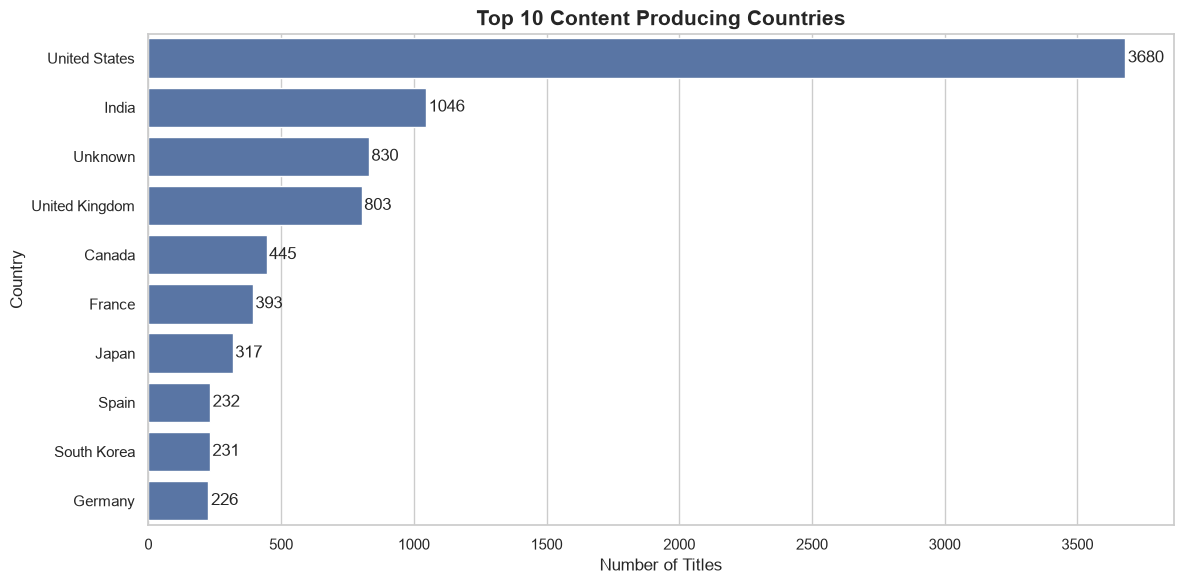

In [365]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

for i, value in enumerate(country_counts.values):
    ax.text(value + 10, i, str(value), va="center")

plt.title("Top 10 Content Producing Countries", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Observation

- The **United States** is the largest content-producing country with **3,680 titles**.
- **India** ranks second with **1,046 titles**, followed by the **United Kingdom (803 titles)**.
- Canada, France, Japan, Spain, South Korea, and Germany are among the other major content-producing countries.

### Key Finding

The United States dominates Netflix's content library, while India is the second-largest contributor, highlighting Netflix's strong presence in both Western and Asian markets.

### Business Insight

The concentration of content in the United States indicates that it is Netflix's primary production and licensing market. India's high ranking reflects the growing importance of regional content and the increasing demand for local-language entertainment. The presence of multiple countries in the top rankings demonstrates Netflix's global content acquisition strategy.

### Recommendation

Netflix should continue strengthening its leadership in the United States while increasing investments in emerging markets such as India, South Korea, Japan, and other high-growth regions. Additionally, improving metadata quality by reducing **Unknown** country values would enhance the accuracy of geographical analysis and business reporting.

## 10.4 Top 10 Directors

In [366]:
director_counts = (
    df_clean[df_clean["director"] != "Unknown"]["director"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

director_counts

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

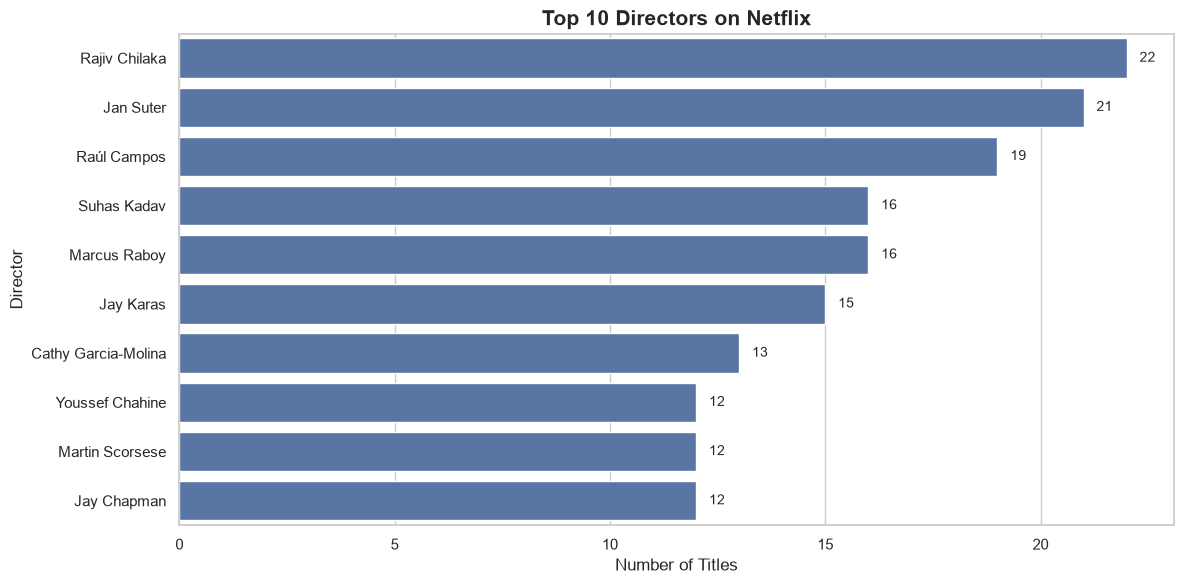

In [367]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=director_counts.values,
    y=director_counts.index
)

for i, value in enumerate(director_counts.values):
    ax.text(value + 0.3, i, str(value), va="center", fontsize=10)

plt.title("Top 10 Directors on Netflix", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.tight_layout()
plt.show()

### Observation

- **Rajiv Chilaka** has the highest number of titles on Netflix with **22** productions.
- **Jan Suter (21)** and **Raúl Campos (19)** are the second and third most represented directors.
- The remaining top directors each contributed between **12 and 16** titles.
- The distribution suggests that Netflix collaborates with multiple directors rather than relying on a single dominant filmmaker.

### Key Finding

No single director dominates Netflix's content library. Instead, content production is distributed across several high-performing directors.

### Business Insight

Working with multiple successful directors helps Netflix maintain content diversity across different genres, languages, and regions. This strategy reduces dependency on individual creators and supports a broader global audience.

### Recommendation

Netflix should continue building long-term partnerships with high-performing directors while identifying emerging filmmakers in growing markets such as India, South Korea, and Japan to further diversify its content portfolio.

## 10.5 Top 10 Actors

In [368]:
actor_counts = (
    df_clean[df_clean["cast"] != "Unknown"]["cast"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

actor_counts

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

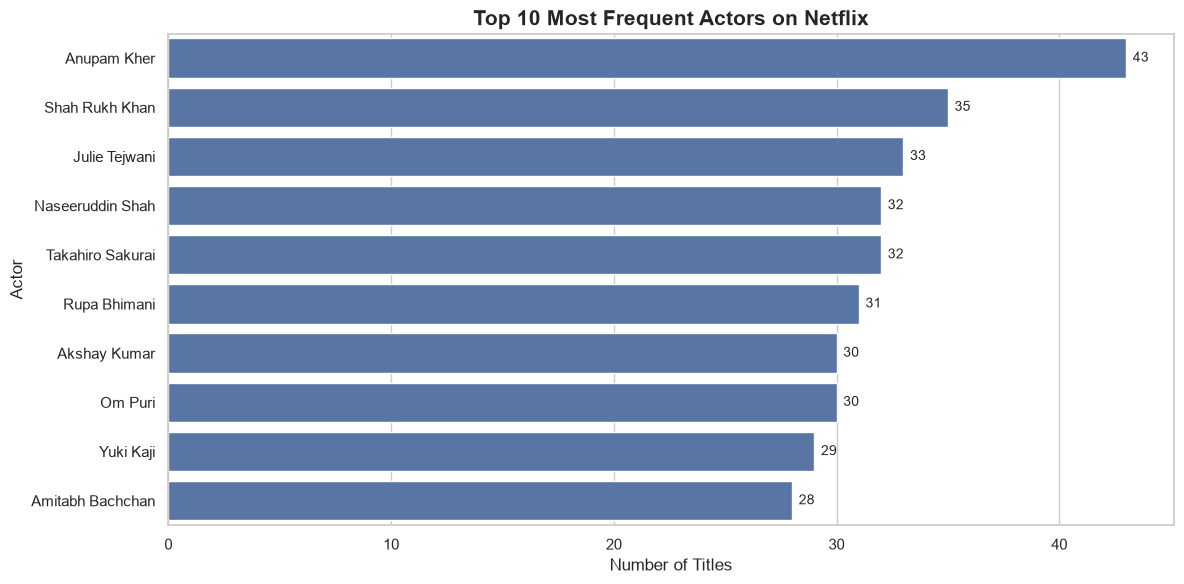

In [369]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=actor_counts.values,
    y=actor_counts.index
)

for i, value in enumerate(actor_counts.values):
    ax.text(value + 0.3, i, str(value), va="center", fontsize=10)

plt.title("Top 10 Most Frequent Actors on Netflix", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.tight_layout()
plt.show()

### Observation

- **Anupam Kher** has the highest number of appearances on Netflix with **43 titles**.
- **Shah Rukh Khan** ranks second with **35 titles**, followed by **Julie Tejwani (33)**.
- Other frequently appearing actors include **Naseeruddin Shah**, **Takahiro Sakurai**, **Rupa Bhimani**, **Akshay Kumar**, **Om Puri**, **Yuki Kaji**, and **Amitabh Bachchan**.
- The top-ranked actors represent multiple film industries, including Bollywood and Japanese animation, reflecting Netflix's diverse global content library.

### Key Finding

Indian actors dominate the top positions, indicating a strong presence of Indian content within Netflix's catalog.

### Business Insight

The high frequency of Indian actors suggests that India is one of Netflix's most important content markets. At the same time, the presence of Japanese voice actors highlights Netflix's growing investment in anime and international entertainment.

### Recommendation

Netflix should continue investing in regional productions featuring well-known local actors while expanding collaborations with international talent. This strategy can strengthen regional subscriber growth and increase global audience engagement.

## 10.6 Content Rating Distribution

In [370]:
rating_counts = df_clean["rating"].value_counts()

rating_counts

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

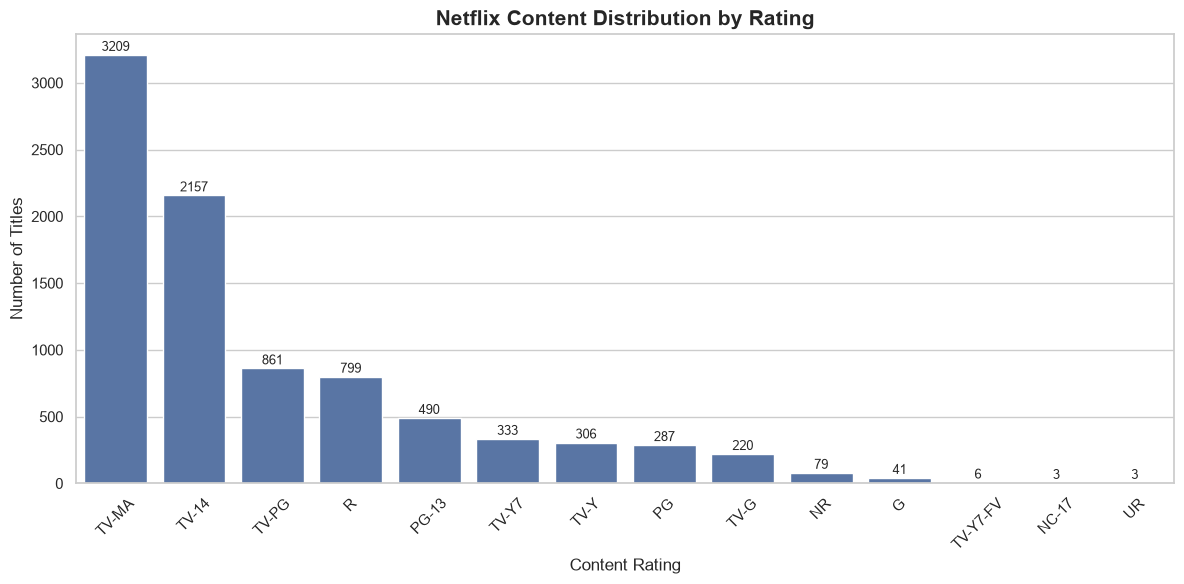

In [371]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

for i, value in enumerate(rating_counts.values):
    ax.text(i, value + 30, str(value), ha="center", fontsize=9)

plt.title("Netflix Content Distribution by Rating", fontsize=15, fontweight="bold")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

- **TV-MA** is the most common content rating on Netflix with **3,209 titles**, followed by **TV-14** with **2,157 titles**.
- Family-friendly ratings such as **TV-PG**, **TV-Y**, **TV-Y7**, **TV-G**, and **PG** are present but represent a smaller portion of the content library.
- Very few titles fall under **NC-17**, **UR**, and **TV-Y7-FV**, making them the least represented rating categories.

### Key Finding

Netflix's content library is primarily targeted toward **teen and adult audiences**, with **TV-MA** and **TV-14** accounting for the largest share of titles.

### Business Insight

The dominance of mature-content ratings suggests that Netflix focuses heavily on content for adult viewers. While this strategy aligns with its global subscriber base, maintaining a balanced content library for children and families is also important to attract a wider audience.

### Recommendation

Netflix should continue investing in high-quality content for adult audiences while expanding family-friendly and children's programming to strengthen household subscriptions and improve long-term customer retention.

## 10.7 Top 10 Genres

In [372]:
genre_counts = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genre_counts

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

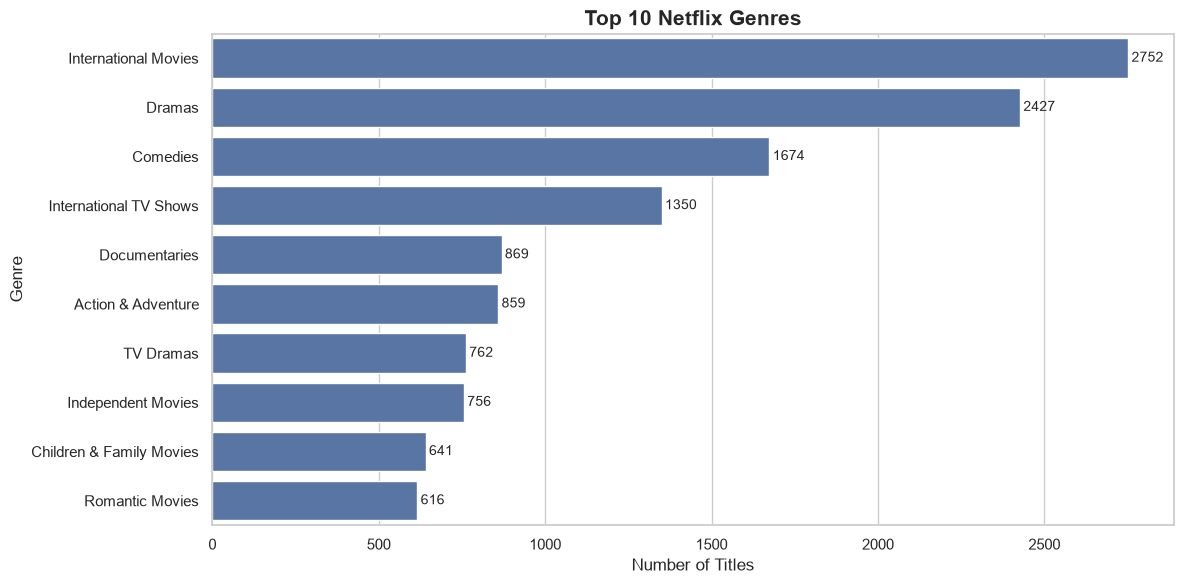

In [373]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

for i, value in enumerate(genre_counts.values):
    ax.text(value + 10, i, str(value), va="center", fontsize=10)

plt.title("Top 10 Netflix Genres", fontsize=15, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

### Observation

- **International Movies** is the most common genre on Netflix with **2,752 titles**.
- **Dramas (2,427)** and **Comedies (1,674)** are the second and third most popular genres.
- **International TV Shows (1,350)** also represent a significant portion of the content library.
- Documentary, Action & Adventure, TV Dramas, Independent Movies, Children & Family Movies, and Romantic Movies are among the top 10 genres.

### Key Finding

Netflix's content library is heavily focused on **international and story-driven content**, with International Movies and Dramas dominating the platform.

### Business Insight

The strong presence of International Movies indicates Netflix's strategy of serving a global audience through localized and multilingual content. The popularity of Drama and Comedy reflects consistent viewer demand for entertainment across different regions.

### Recommendation

Netflix should continue expanding international productions while increasing investments in high-demand genres such as Drama and Comedy. At the same time, identifying underrepresented genres with growth potential can help diversify the content library and attract new audience segments.

## 10.8 Movie Duration Analysis

In [374]:
movies = df_clean[df_clean["type"] == "Movie"].copy()

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,content_age,month_added,day_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,1.0,September,Saturday,90,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,0.0,September,Friday,91,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,28.0,September,Friday,125,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,0.0,September,Friday,104,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,0.0,September,Thursday,127,min


In [375]:
movies["duration_value"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

### Observation

- The dataset contains **6,128 movies**.
- The **average movie duration** is approximately **99.6 minutes**.
- The **median duration** is **98 minutes**, indicating that most movies are close to 1.5–2 hours long.
- The **shortest movie** is **3 minutes**, while the **longest movie** is **312 minutes**.
- The middle 50% of movies have durations between **87 and 114 minutes**, showing that most Netflix movies fall within a relatively consistent runtime range.

### Key Finding

Most Netflix movies are approximately **100 minutes** long, suggesting a standardized runtime that aligns with viewer preferences and industry norms.

### Business Insight

A runtime of around **90–110 minutes** is common because it provides enough time for storytelling while maintaining audience engagement. Extremely short or very long movies are relatively uncommon and likely target specific audiences or genres.

### Recommendation

Netflix should continue investing in movies within the **90–110 minute** range while selectively producing shorter and longer content for niche audiences. Analyzing viewer engagement by movie duration can further optimize content production decisions.

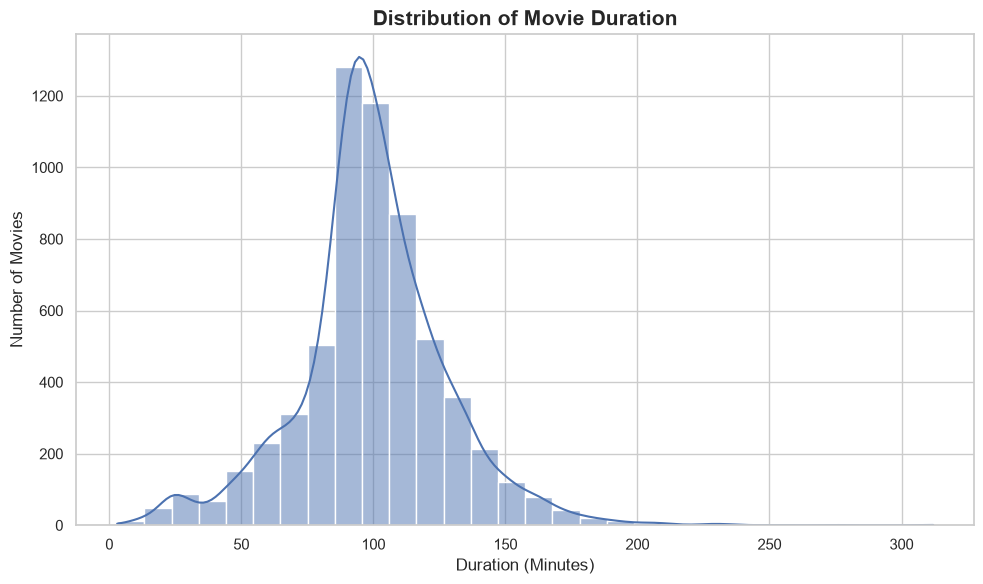

In [376]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies["duration_value"],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration", fontsize=15, fontweight="bold")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

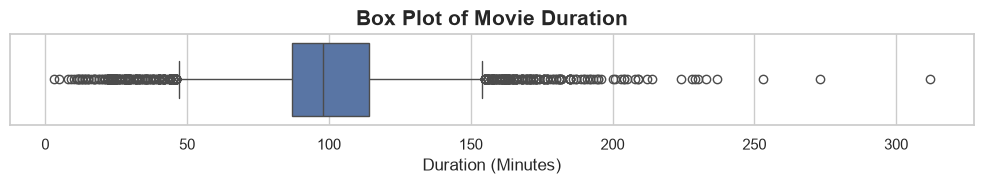

In [377]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=movies["duration_value"]
)

plt.title("Box Plot of Movie Duration", fontsize=15, fontweight="bold")
plt.xlabel("Duration (Minutes)")

plt.tight_layout()
plt.show()

In [378]:
movies.nlargest(10, "duration_value")[["title", "duration_value", "release_year", "country"]]

,title,duration_value,release_year,country
4253,Black Mirror: Bandersnatch,312,2018,United States
717,Headspace: Unwind Your Mind,273,2021,Unknown
2491,The School of Mischief,253,1973,Egypt
2487,No Longer kids,237,1979,Egypt
2484,Lock Your Girls In,233,1982,Unknown
2488,Raya and Sakina,230,1984,Unknown
166,Once Upon a Time in America,229,1984,"Italy, United States"
7932,Sangam,228,1964,India
1019,Lagaan,224,2001,"India, United Kingdom"
4573,Jodhaa Akbar,214,2008,India


### Observation

- The longest movie in the dataset is **Black Mirror: Bandersnatch** with a duration of **312 minutes**.
- Other long-duration titles include **Headspace: Unwind Your Mind (273 minutes)** and **The School of Mischief (253 minutes)**.
- The top 10 longest movies originate from multiple countries, including the **United States, Egypt, Italy, India,** and the **United Kingdom**.
- Most of the longest movies were released between the **1960s and 2020s**, indicating that long-duration content has existed across different eras.

### Key Finding

Although the average Netflix movie is approximately **100 minutes**, a small number of movies exceed **200 minutes**, representing a niche segment of the content library.

### Business Insight

Long-duration movies are generally targeted toward audiences interested in epic stories, historical dramas, documentaries, or experimental content. Maintaining a diverse catalog with both standard-length and long-form movies helps Netflix serve different viewer preferences.

### Recommendation

Netflix should continue offering a balanced mix of standard-length and long-duration movies. Viewer engagement metrics should be analyzed to determine whether very long movies generate sufficient watch time and subscriber satisfaction.

## 10.9 TV Show Seasons Analysis

In [379]:
tv_shows = df_clean[df_clean["type"] == "TV Show"].copy()

tv_shows["duration_value"].describe()

count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64

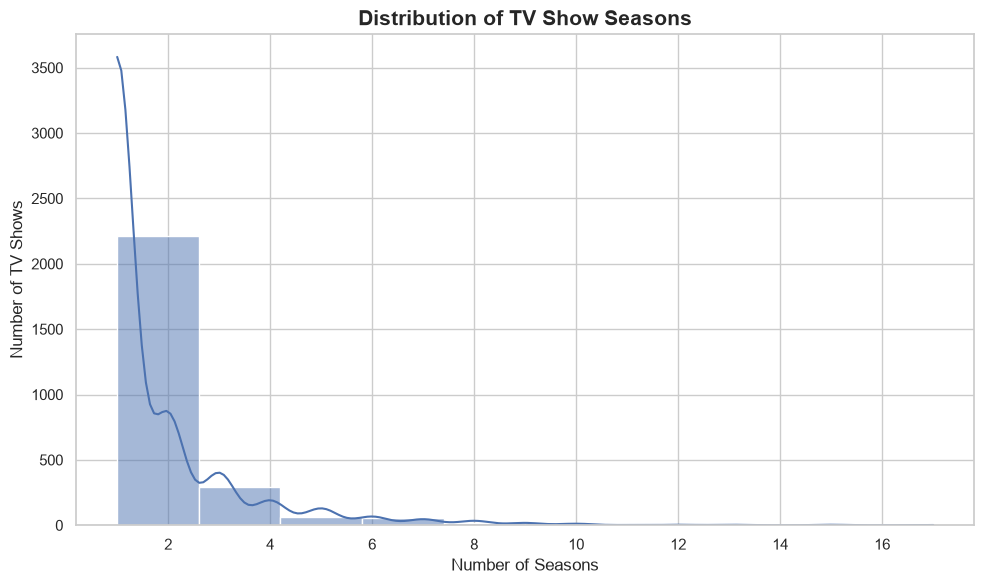

In [380]:
plt.figure(figsize=(10,6))

sns.histplot(
    tv_shows["duration_value"],
    bins=10,
    kde=True
)

plt.title("Distribution of TV Show Seasons", fontsize=15, fontweight="bold")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.tight_layout()
plt.show()

### Observation

- The dataset contains **2,666 TV Shows**.
- The **average TV Show length** is approximately **1.75 seasons**.
- The **median** is **1 season**, indicating that more than half of the TV Shows consist of only a single season.
- The **maximum** number of seasons is **17**, while the minimum is **1 season**.
- The middle 50% of TV Shows have between **1 and 2 seasons**, showing that Netflix's catalog is dominated by short-running series.

### Key Finding

Most TV Shows on Netflix are limited to **1–2 seasons**, while long-running series are relatively uncommon.

### Business Insight

A catalog dominated by short series suggests that Netflix focuses on limited series, mini-series, and newer productions. Shorter series are generally less expensive to produce, faster to release, and easier for viewers to binge-watch.

### Recommendation

Netflix should continue investing in high-quality limited series while renewing only those shows that demonstrate strong audience engagement and viewing completion rates. This approach helps optimize production costs and maximize subscriber satisfaction.

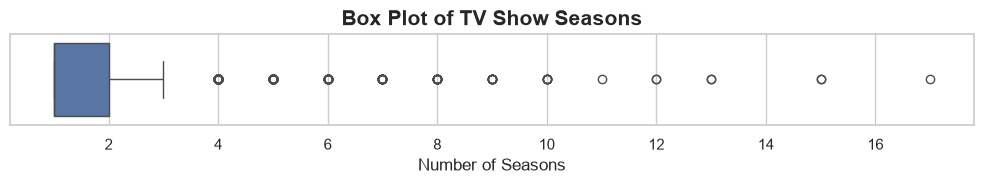

In [381]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=tv_shows["duration_value"]
)

plt.title("Box Plot of TV Show Seasons", fontsize=15, fontweight="bold")
plt.xlabel("Number of Seasons")

plt.tight_layout()
plt.show()

## 10.10 Monthly Content Addition

In [382]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_content = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

monthly_content

month_added
January      738
February     563
March        742
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     813
Name: count, dtype: int64

### Observation

- Netflix added content consistently throughout the year, with noticeable variation across months.
- **July** recorded the highest number of content additions (**827 titles**), followed by **December (813)** and **September (769)**.
- **February** had the lowest number of content additions (**563 titles**).
- Overall, the monthly distribution is relatively balanced, indicating that Netflix releases new content throughout the year rather than concentrating it in a single season.

### Key Finding

The highest volume of content was added during **July**, while **February** experienced the lowest level of content additions.

### Business Insight

The increase in content additions during **July** and **December** may align with periods of higher audience engagement, such as summer vacations and year-end holidays, when viewers generally spend more time streaming. Maintaining a steady release schedule throughout the year also helps keep subscribers engaged.

### Recommendation

Netflix should continue following a consistent release strategy while maximizing content launches during high-engagement months such as **July** and **December**. Further analysis of viewer watch time and subscriber growth by month can help optimize future release schedules.

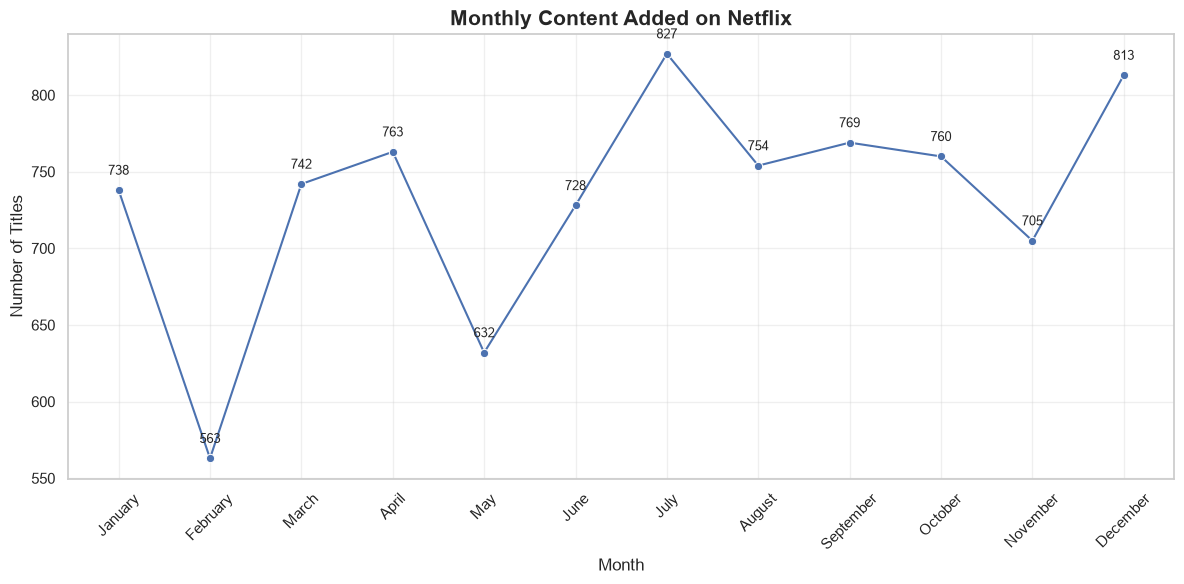

In [383]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=monthly_content.index,
    y=monthly_content.values,
    marker="o"
)

for i, value in enumerate(monthly_content.values):
    plt.text(i, value + 10, str(value), ha="center", fontsize=9)

plt.title("Monthly Content Added on Netflix", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10.11 Weekday Content Addition

In [384]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_content = (
    df_clean["day_added"]
    .value_counts()
    .reindex(day_order)
)

weekday_content

day_added
Monday        850
Tuesday      1196
Wednesday    1288
Thursday     1396
Friday       2497
Saturday      816
Sunday        751
Name: count, dtype: int64

### Observation

- **Friday** recorded the highest number of content additions with **2,497 titles**, making it the most active day for Netflix releases.
- **Thursday (1,396)** and **Wednesday (1,288)** are the second and third most active days.
- **Sunday (751)** has the lowest number of content additions, followed by **Saturday (816)**.
- The distribution shows that Netflix prefers releasing new content on weekdays rather than weekends.

### Key Finding

Netflix follows a clear release strategy by launching most of its content on **Fridays**, just before the weekend.

### Business Insight

Releasing content on Fridays allows subscribers to watch newly released titles during the weekend when engagement is generally higher. This strategy can increase watch time, improve user satisfaction, and generate more social media discussions over the weekend.

### Recommendation

Netflix should continue prioritizing Friday releases for major titles while experimenting with mid-week releases for selected regional or niche content. A/B testing different release days could further optimize viewer engagement.

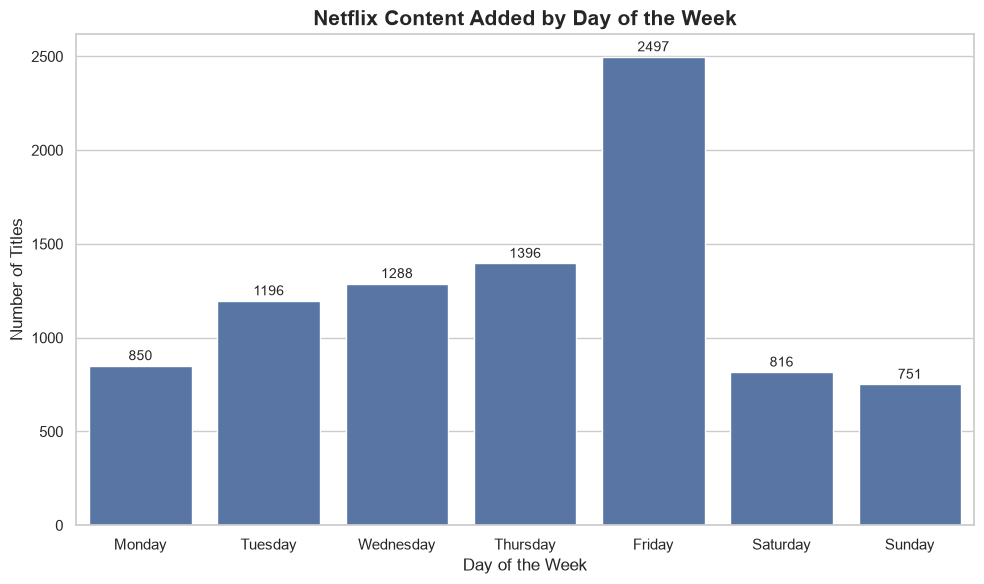

In [385]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=weekday_content.index,
    y=weekday_content.values
)

for i, value in enumerate(weekday_content.values):
    ax.text(i, value + 30, str(value), ha="center", fontsize=10)

plt.title("Netflix Content Added by Day of the Week", fontsize=15, fontweight="bold")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

## 10.12 Release Year Trend

In [386]:
release_trend = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

release_trend

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
1946       2
1947       1
1954       2
1955       3
1956       2
1958       3
1959       1
1960       4
1961       1
1962       3
1963       2
1964       2
1965       2
1966       1
1967       5
1968       3
1969       2
1970       2
1971       5
1972       5
1973      10
1974       7
1975       7
1976       9
1977       7
1978       7
1979      11
1980      11
1981      13
1982      17
1983      11
1984      12
1985      10
1986      13
1987       8
1988      18
1989      16
1990      22
1991      17
1992      23
1993      28
1994      22
1995      25
1996      24
1997      38
1998      36
1999      39
2000      37
2001      45
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     287
2014     352
2015     557
2016     901
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [387]:
release_trend.sort_values(ascending=False).head(10)

release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
2021     592
2015     557
2014     352
2013     287
2012     236
Name: count, dtype: int64

In [388]:
df_clean["release_year"].describe()

count    8794.000000
mean     2014.183534
std         8.823527
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

### Why This Analysis Matters

Analyzing release years helps identify whether Netflix's catalog is dominated by recent or older content. This provides insights into content acquisition strategy, catalog freshness, and the balance between modern and classic titles.

### Observation

- The dataset contains content released between **1925 and 2021**.
- **2018** recorded the highest number of released titles with **1,146 titles**.
- This was followed by **2017 (1,031 titles)** and **2019 (1,030 titles)**.
- The average release year is approximately **2014**.
- The median release year is **2017**, indicating that at least half of the titles were released in or after 2017.
- Approximately 75% of the content was released in or after **2013**.
- The data shows a strong concentration of recently released content.

### Key Finding

Netflix's catalog is heavily dominated by modern content, particularly titles released between **2016 and 2020**, with **2018** representing the peak release year.

### Business Insight

The strong concentration of recent titles suggests that Netflix prioritizes catalog freshness and modern entertainment. Recent content may help attract viewers seeking current productions, while older titles provide catalog diversity and serve audiences interested in classic content.

### Recommendation

Netflix should continue acquiring and producing recent content while maintaining a carefully selected collection of classic titles. Viewer engagement by release decade should be analyzed to determine the optimal balance between modern and legacy content.

In [389]:
import plotly.express as px

# 1. Release year ke counts ko extract aur sort karna
release_counts = df_clean['release_year'].value_counts().reset_index()
release_counts.columns = ['Release Year', 'Count']
release_counts = release_counts.sort_values(by='Release Year')

# 2. Premium Interactive Line Chart create karna
fig = px.line(
    release_counts, 
    x='Release Year', 
    y='Count', 
    title='🎬 Historical Netflix Content Release Trends Over the Years (1925 - 2021)',
    labels={'Count': 'Number of Titles Released', 'Release Year': 'Year of Release'},
    template='plotly_dark' # Professional Dark Mode Theme
)

# 3. Chart Customization (Premium Netflix Red Styling)
fig.update_traces(
    line_color='#E50914', # Netflix Signature Red Color
    line_width=3.5,
    mode='lines+markers', # Line ke sath nodes/points bhi show honge
    marker=dict(size=6, color='#FFFFFF', symbol='circle') # White markers premium look ke liye
)

# 4. Layout configuration for a clean corporate feel
fig.update_layout(
    title_font_size=20,
    xaxis=dict(
        showgrid=False,
        dtick=10, # Har 10 saal par axis text show hoga
        title_font=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#2F2F2F', # Muted gridlines for cleaner interface
        title_font=dict(size=14)
    ),
    hovermode="x unified" # Hover karne par automatically poore vertical axis ka data dikhega
)

fig.show()

## 10.13 Movies vs TV Shows Release Trend

In [390]:
type_release_trend = (
    df_clean
    .groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)

type_release_trend.head()

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


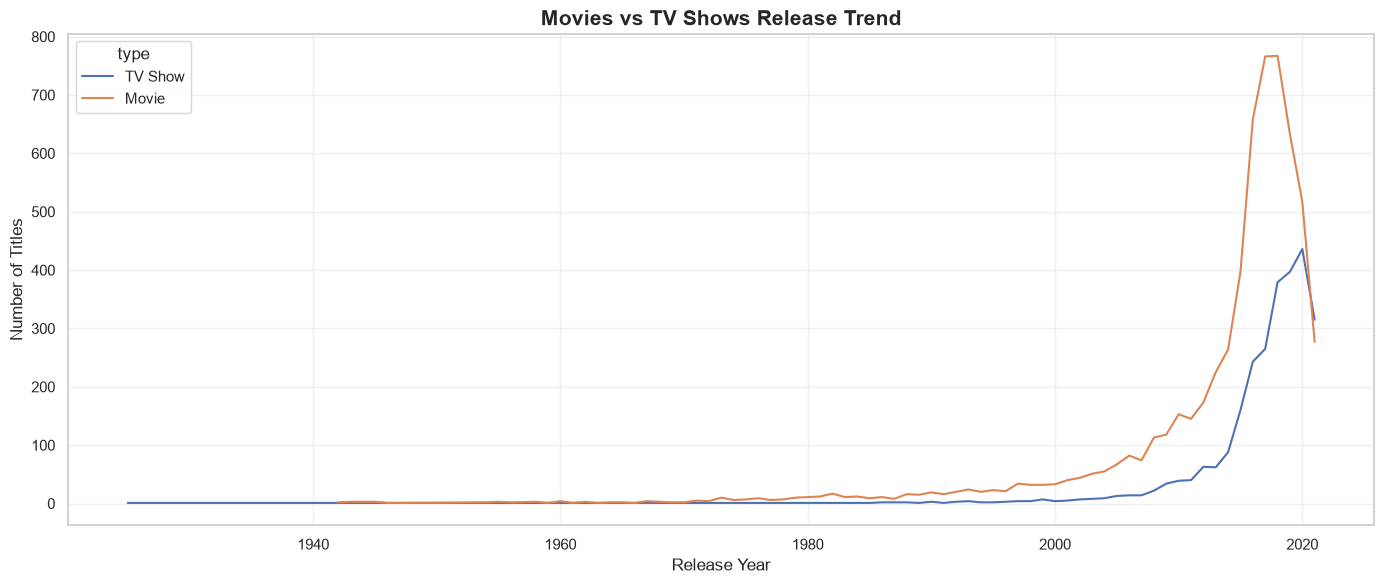

In [391]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=type_release_trend,
    x="release_year",
    y="count",
    hue="type"
)

plt.title(
    "Movies vs TV Shows Release Trend",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [392]:
type_release_trend.loc[
    type_release_trend.groupby("type")["count"].idxmax()
]

,release_year,type,count
111,2018,Movie,767
116,2020,TV Show,436


### Why This Analysis Matters

Comparing Movies and TV Shows over time helps identify changes in Netflix's content strategy and understand how investment in different content formats has evolved.

### Observation

- Movies reached their highest release count in **2018**, with **767 titles**.
- TV Shows reached their highest release count in **2020**, with **436 titles**.
- Movies historically represent a larger portion of the Netflix catalog.
- The later peak of TV Shows indicates increasing growth in episodic content.
- The trend suggests that Netflix's content portfolio has gradually expanded beyond movies toward TV-based entertainment.

### Key Finding

Movies peaked earlier in **2018**, while TV Shows reached their highest release count in **2020**, indicating a later expansion of episodic content.

### Business Insight

The growth of TV Shows may reflect Netflix's increasing focus on long-term viewer engagement. Unlike standalone movies, episodic content can encourage repeated platform usage and longer viewing sessions.

### Recommendation

Netflix should maintain a balanced content portfolio by using Movies for catalog diversity and broad audience reach while investing in high-performing TV Shows that can support long-term viewer engagement and subscriber retention.

## 10.14 Multi-Country Productions

In [393]:
multi_country = df_clean[
    df_clean["country"].str.contains(",", na=False)
]

multi_country.shape[0]

1320

### Why This Analysis Matters

Analyzing multi-country productions helps measure international collaboration within Netflix's content catalog and provides insight into the platform's global content strategy.

### Observation

- The dataset contains **1,320 titles** produced through collaborations involving multiple countries.
- These titles represent international co-productions rather than content associated with a single country.
- This indicates a noticeable presence of cross-country collaboration within Netflix's catalog.

### Key Finding

Netflix's catalog includes **1,320 multi-country productions**, highlighting the role of international collaboration in its global content portfolio.

### Business Insight

International co-productions can combine talent, production resources, and storytelling perspectives from different markets. This may help Netflix create content with broader regional and international appeal.

### Recommendation

Netflix should continue exploring strategic international co-productions, particularly between established and growing content markets. Performance metrics should be used to identify country partnerships that generate strong cross-regional engagement.

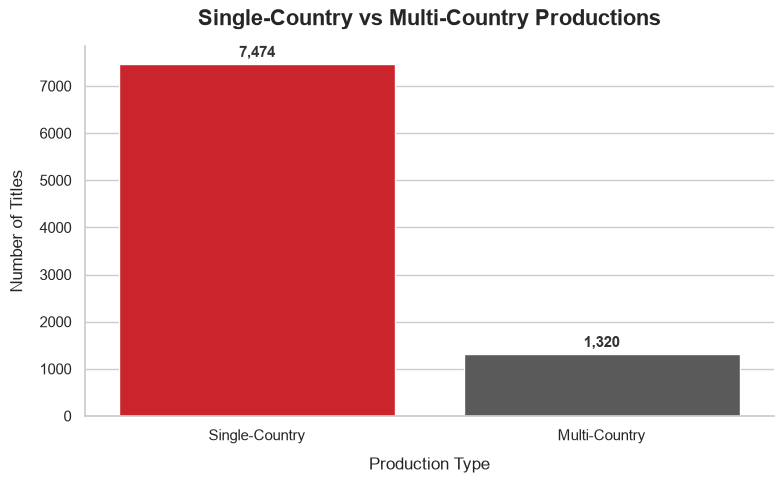

In [394]:
import matplotlib.pyplot as plt
import seaborn as sns

# Series data prep (Aapka logic perfect hai)
production_type = pd.Series({
    "Single-Country": len(df_clean) - len(multi_country),
    "Multi-Country": len(multi_country)
})

# Plot styling
plt.figure(figsize=(8, 5))

# Custom Premium Palette (Highlighting Single-Country with a solid color)
colors = ["#E50914", "#5A5A5A"]  # Netflix Red and Muted Gray

ax = sns.barplot(
    x=production_type.index,
    y=production_type.values,
    palette=colors,
    hue=production_type.index,  # Avoiding future warnings
    legend=False
)

# Text labels on top of bars
for i, value in enumerate(production_type.values):
    ax.text(
        i, 
        value + (max(production_type.values) * 0.01),  # Dynamic spacing on top of bar
        f"{value:,}",                                  # Formatted with commas
        ha="center", 
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

# Title and Labels
plt.title(
    "Single-Country vs Multi-Country Productions",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Production Type", fontsize=12, labelpad=10)
plt.ylabel("Number of Titles", fontsize=12, labelpad=10)

# Clean up axes (Removing top and right borders for a modern look)
sns.despine()
plt.tight_layout()

# Save the plot for the audit report
plt.savefig("production_type_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

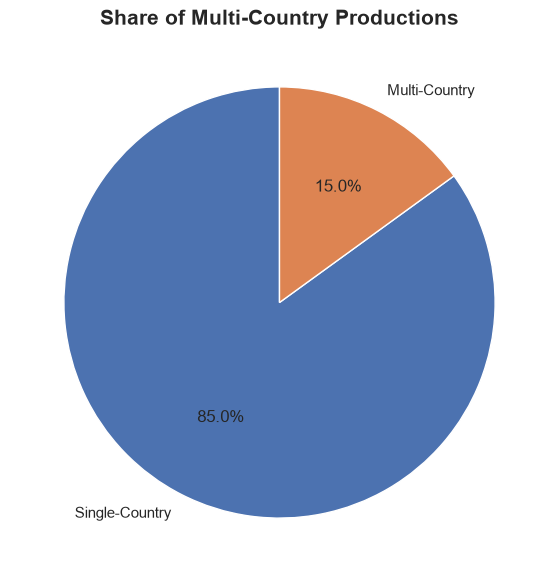

In [395]:
plt.figure(figsize=(7, 7))

plt.pie(
    production_type.values,
    labels=production_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Share of Multi-Country Productions",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 10.15 Movie Content Age Analysis

This analysis examines the number of years between a movie's original release year and the year it was added to Netflix.

In [396]:
movies_age = df_clean[df_clean["type"] == "Movie"].copy()

In [397]:
movies_age["content_age"] = (
    movies_age["year_added"] - movies_age["release_year"]
)

In [398]:
movies_age[movies_age["content_age"] < 0][
    ["title", "release_year", "year_added", "content_age"]
]

,title,release_year,year_added,content_age
5394,Hans Teeuwen: Real Rancour,2018,2017,-1
7063,Incoming,2019,2018,-1


In [399]:
valid_movies_age = movies_age[
    movies_age["content_age"] >= 0
].copy()

In [400]:
valid_movies_age["content_age"].describe()

count    6126.000000
mean        5.731636
std         9.745386
min         0.000000
25%         0.000000
50%         2.000000
75%         7.000000
max        75.000000
Name: content_age, dtype: float64

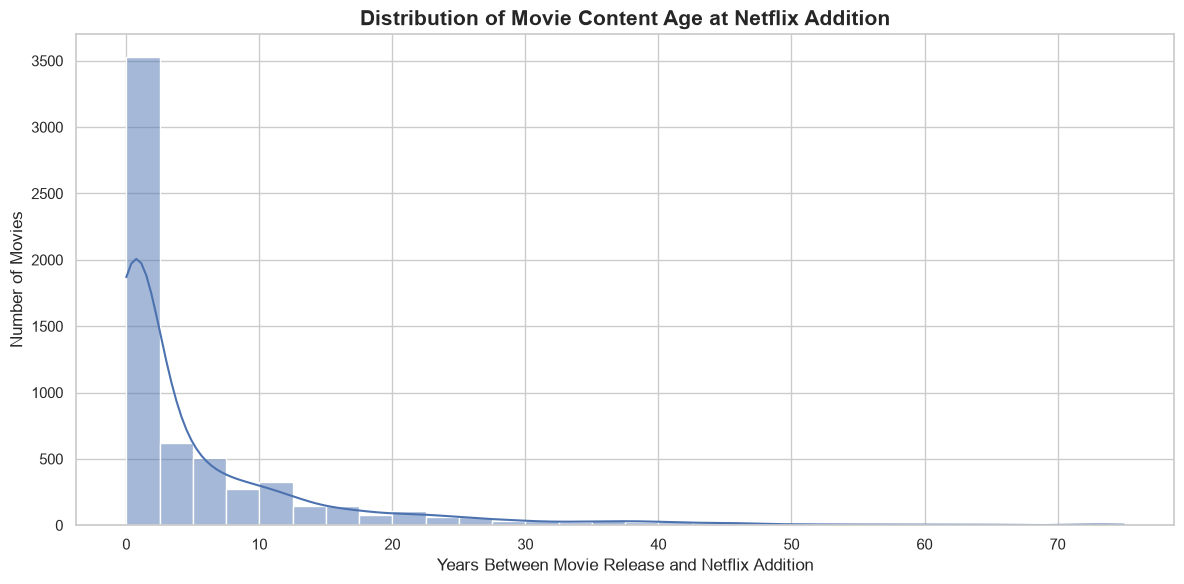

In [401]:
plt.figure(figsize=(12, 6))

sns.histplot(
    valid_movies_age["content_age"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Movie Content Age at Netflix Addition",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Years Between Movie Release and Netflix Addition")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

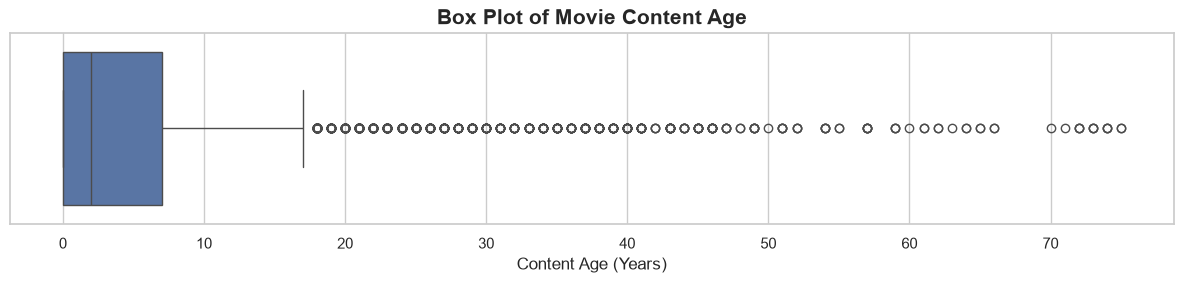

In [402]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=valid_movies_age["content_age"]
)

plt.title(
    "Box Plot of Movie Content Age",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Age (Years)")

plt.tight_layout()
plt.show()

In [403]:
bins = [-1, 0, 2, 5, 10, 20, float("inf")]

labels = [
    "Same Year",
    "1-2 Years",
    "3-5 Years",
    "6-10 Years",
    "11-20 Years",
    "20+ Years"
]

valid_movies_age["age_category"] = pd.cut(
    valid_movies_age["content_age"],
    bins=bins,
    labels=labels
)

age_category_counts = (
    valid_movies_age["age_category"]
    .value_counts()
    .sort_index()
)

age_category_counts

age_category
Same Year      1861
1-2 Years      1668
3-5 Years       811
6-10 Years      711
11-20 Years     613
20+ Years       462
Name: count, dtype: int64

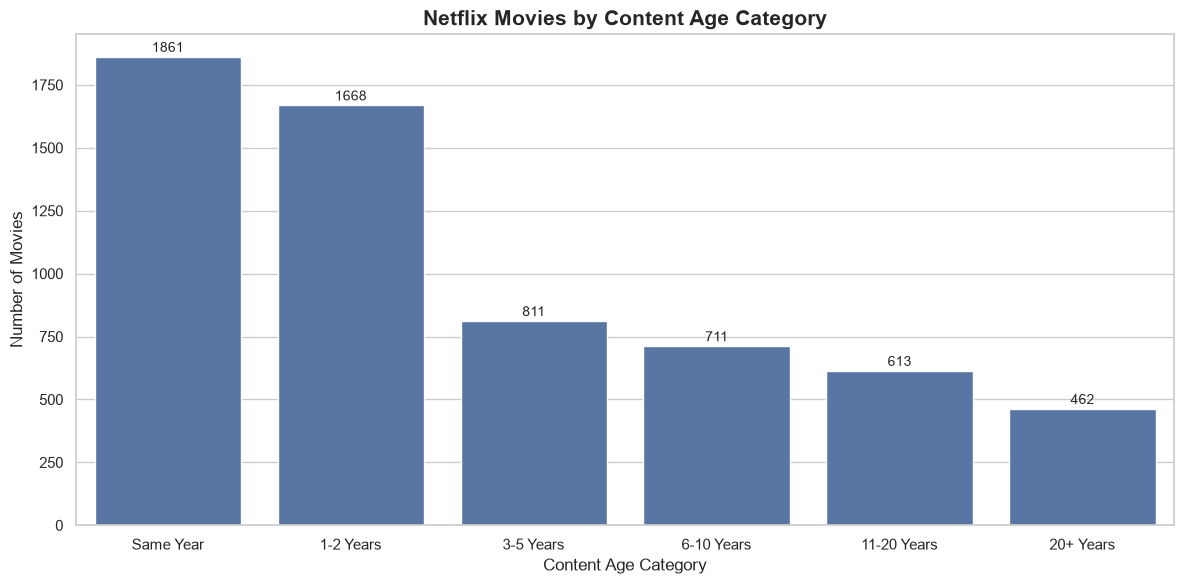

In [404]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=age_category_counts.index,
    y=age_category_counts.values
)

for i, value in enumerate(age_category_counts.values):
    ax.text(i, value + 20, str(value), ha="center", fontsize=10)

plt.title(
    "Netflix Movies by Content Age Category",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Age Category")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

### Why This Analysis Matters

Movie content age analysis helps evaluate how quickly movies are added to Netflix after their original release and provides insight into the balance between recent and older content.

### Data Quality Note

- Two movies contained negative content age values due to inconsistencies between their release year and Netflix addition year.
- These records were retained in the original dataset but excluded from the content age analysis to avoid misleading statistical results.

### Observation

- The analysis includes **6,126 valid movies**.
- The average movie content age is approximately **5.73 years**, while the median is only **2 years**.
- **1,861 movies** were added to Netflix in the same year they were released.
- **1,668 movies** were added within **1–2 years** of release.
- **811 movies** were added within **3–5 years**.
- **711 movies** were added within **6–10 years**.
- The catalog also contains **613 movies aged 11–20 years** and **462 movies older than 20 years**.
- The oldest valid movie addition gap is **75 years**.

### Key Finding

More than half of the analyzed movies were added to Netflix within two years of their original release, indicating a strong concentration of relatively recent content.

### Business Insight

The low median content age suggests that Netflix's movie catalog focuses strongly on recent titles. However, the presence of older movies also contributes to catalog diversity and supports audiences interested in classic content.

### Recommendation

Netflix should maintain a strong pipeline of recently released movies while selectively acquiring classic titles based on audience demand. Content age should be combined with watch-time and engagement metrics to evaluate whether newer or older movies generate greater viewer value.

## 10.16 Movie Duration Outlier Analysis

This analysis identifies unusually short and long movies using the Interquartile Range (IQR) statistical method.

In [405]:
Q1 = movies["duration_value"].quantile(0.25)
Q3 = movies["duration_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound

(np.float64(87.0),
 np.float64(114.0),
 np.float64(27.0),
 np.float64(46.5),
 np.float64(154.5))

In [406]:
duration_outliers = movies[
    (movies["duration_value"] < lower_bound) |
    (movies["duration_value"] > upper_bound)
]

duration_outliers.shape[0]

450

In [407]:
short_outliers = movies[
    movies["duration_value"] < lower_bound
]

long_outliers = movies[
    movies["duration_value"] > upper_bound
]

print("Short Duration Outliers:", short_outliers.shape[0])
print("Long Duration Outliers:", long_outliers.shape[0])
print("Total Duration Outliers:", duration_outliers.shape[0])

Short Duration Outliers: 249
Long Duration Outliers: 201
Total Duration Outliers: 450


In [408]:
outlier_percentage = (
    len(duration_outliers) / len(movies)
) * 100

outlier_percentage

7.343342036553525

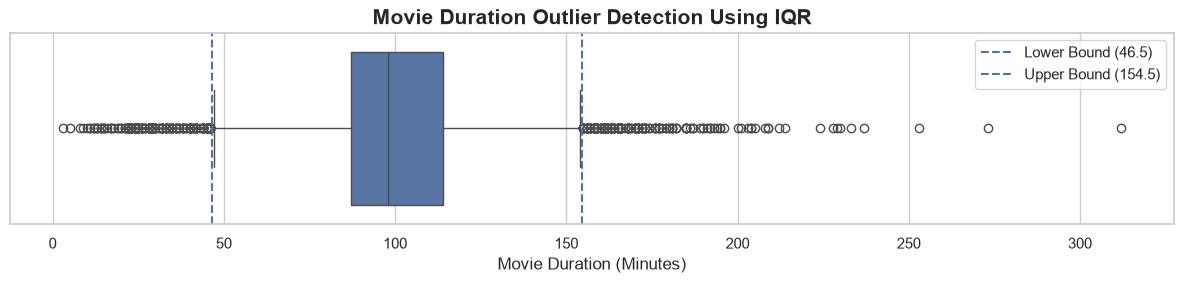

In [409]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=movies["duration_value"]
)

plt.axvline(
    lower_bound,
    linestyle="--",
    label=f"Lower Bound ({lower_bound:.1f})"
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper Bound ({upper_bound:.1f})"
)

plt.title(
    "Movie Duration Outlier Detection Using IQR",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Movie Duration (Minutes)")
plt.legend()

plt.tight_layout()
plt.show()

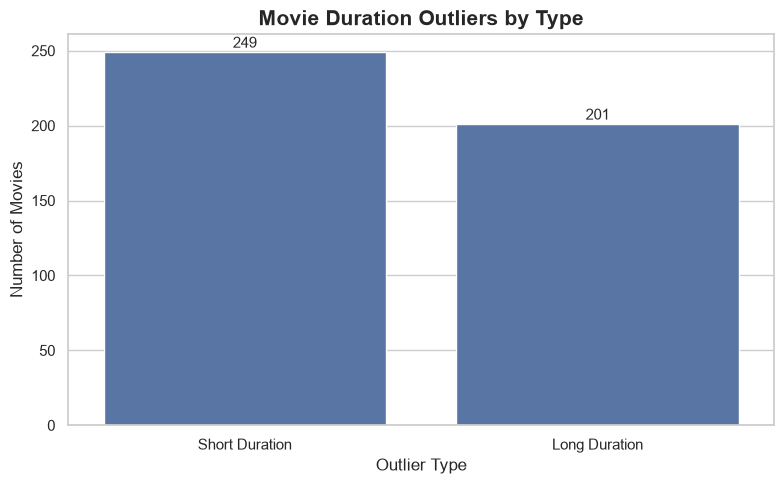

In [410]:
outlier_types = pd.Series({
    "Short Duration": len(short_outliers),
    "Long Duration": len(long_outliers)
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=outlier_types.index,
    y=outlier_types.values
)

for i, value in enumerate(outlier_types.values):
    ax.text(i, value + 3, str(value), ha="center", fontsize=11)

plt.title(
    "Movie Duration Outliers by Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Outlier Type")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

### Why This Analysis Matters

Outlier analysis helps identify movies with unusually short or long durations and determines whether extreme runtime values represent data quality issues or valid content variations.

### Observation

- The first quartile (Q1) of movie duration is **87 minutes**, while the third quartile (Q3) is **114 minutes**.
- The Interquartile Range (IQR) is **27 minutes**.
- Using the IQR method, movies shorter than **46.5 minutes** or longer than **154.5 minutes** were identified as potential statistical outliers.
- A total of **450 movies** were identified as duration outliers.
- **249 movies** were classified as short-duration outliers.
- **201 movies** were classified as long-duration outliers.
- Duration outliers represent approximately **7.34%** of all movies in the dataset.

### Key Finding

Approximately **7.34% of Netflix movies have unusually short or long runtimes** based on the IQR statistical method.

### Business Insight

The presence of duration outliers indicates diversity in Netflix's movie catalog. Short-form and extended-duration content may serve different audience preferences and content formats.

### Analytical Decision

The identified outliers were not removed because statistical outliers do not automatically represent incorrect data. Extreme movie durations may represent valid content and should be investigated before removal.

### Recommendation

Netflix should analyze viewer engagement and completion rates across different movie duration groups. This can help determine whether short-form or long-duration movies provide meaningful viewer value and support future content acquisition decisions.

## 10.17 Movie Duration Categories Analysis

This analysis segments movies into duration categories to understand the distribution of short, standard, long, and extended-length content.

In [411]:
duration_bins = [0, 60, 120, 180, float("inf")]

duration_labels = [
    "Short (≤60 min)",
    "Standard (61-120 min)",
    "Long (121-180 min)",
    "Extended (180+ min)"
]

movies["duration_category"] = pd.cut(
    movies["duration_value"],
    bins=duration_bins,
    labels=duration_labels
)

duration_category_counts = (
    movies["duration_category"]
    .value_counts()
    .sort_index()
)

duration_category_counts

duration_category
Short (≤60 min)           487
Standard (61-120 min)    4499
Long (121-180 min)       1095
Extended (180+ min)        47
Name: count, dtype: int64

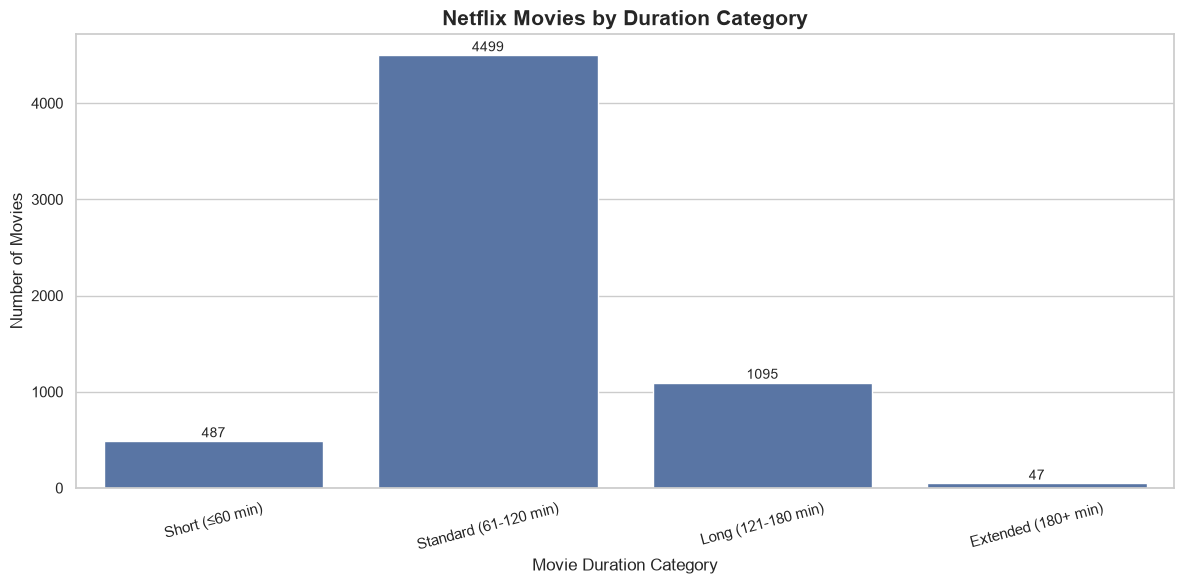

In [412]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=duration_category_counts.index,
    y=duration_category_counts.values
)

for i, value in enumerate(duration_category_counts.values):
    ax.text(i, value + 40, str(value), ha="center", fontsize=10)

plt.title(
    "Netflix Movies by Duration Category",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Movie Duration Category")
plt.ylabel("Number of Movies")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [413]:
duration_category_percentage = (
    duration_category_counts / duration_category_counts.sum()
) * 100

duration_category_percentage.round(2)

duration_category
Short (≤60 min)           7.95
Standard (61-120 min)    73.42
Long (121-180 min)       17.87
Extended (180+ min)       0.77
Name: count, dtype: float64

### Why This Analysis Matters

Movie duration segmentation helps understand the structure of Netflix's movie catalog and identifies which runtime categories dominate the platform.

### Observation

- **4,499 movies (73.42%)** fall within the standard duration range of **61–120 minutes**.
- **1,095 movies (17.87%)** are classified as long movies with durations between **121 and 180 minutes**.
- **487 movies (7.95%)** have durations of **60 minutes or less**.
- Only **47 movies (0.77%)** are extended-length movies with durations greater than **180 minutes**.
- Standard-duration movies clearly dominate Netflix's movie catalog.

### Key Finding

Approximately **73.42% of Netflix movies are between 61 and 120 minutes long**, making standard-length movies the dominant runtime category.

### Business Insight

The strong concentration of movies within the 61–120 minute range indicates that Netflix's catalog is primarily structured around conventional movie runtimes. Short, long, and extended movies provide additional content diversity but represent smaller portions of the catalog.

### Recommendation

Netflix should maintain a strong portfolio of standard-length movies while using viewer engagement and completion-rate data to evaluate demand for short-form, long, and extended-duration content.

## 10.18 Rating Distribution by Content Type

This analysis compares content ratings across Movies and TV Shows to understand how rating categories are distributed between different content formats.

In [414]:
rating_type = pd.crosstab(
    df_clean["rating"],
    df_clean["type"]
)

rating_type

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2064,1145


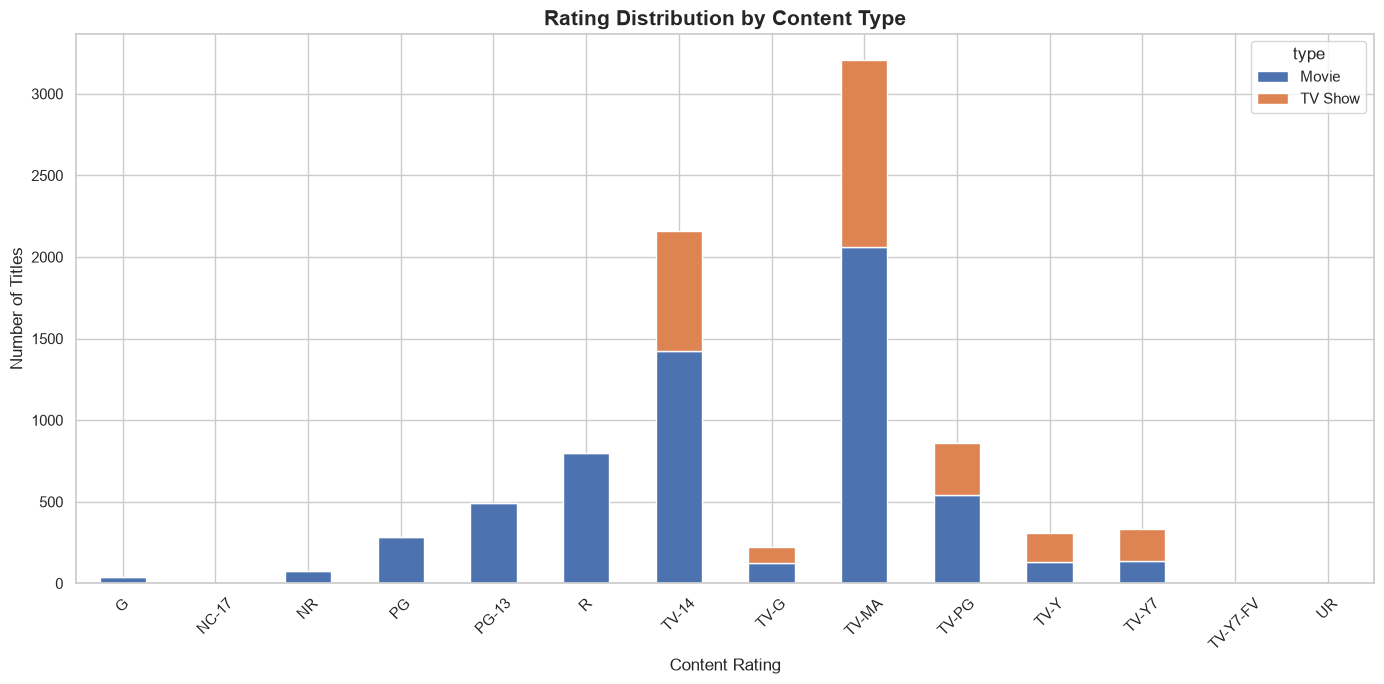

In [415]:
rating_type.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title(
    "Rating Distribution by Content Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

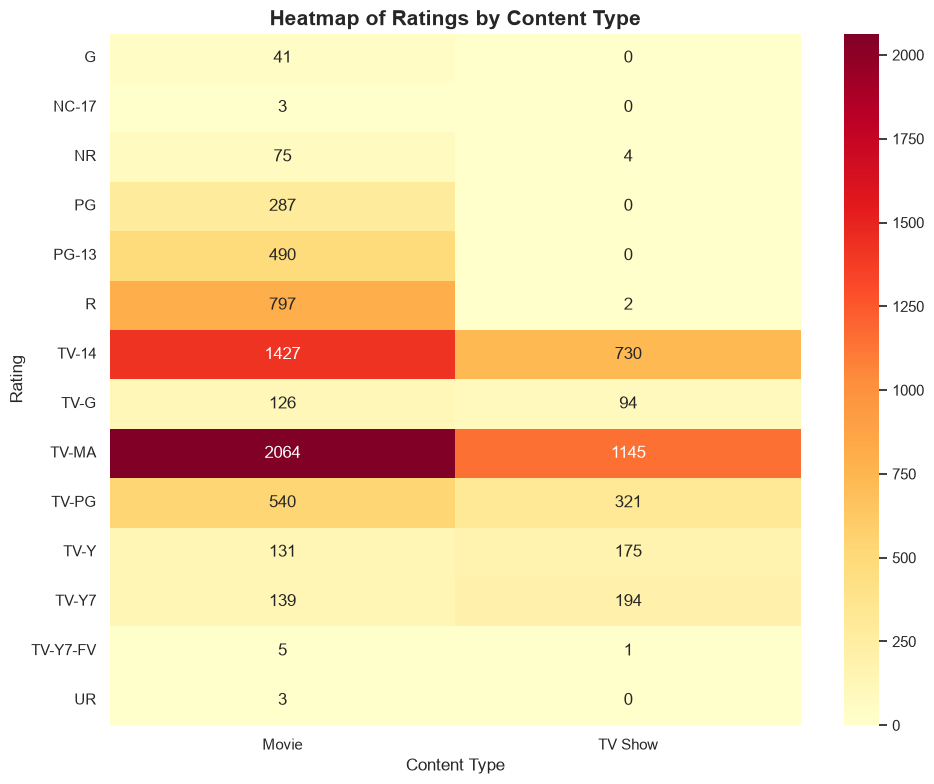

In [416]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_type,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title(
    "Heatmap of Ratings by Content Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

### Why This Analysis Matters

Comparing ratings across Movies and TV Shows helps identify how audience classification patterns differ between content formats.

### Observation

- **TV-MA** is the dominant rating for both Movies and TV Shows, with **2,064 Movies** and **1,145 TV Shows**.
- **TV-14** is the second most common rating, containing **1,427 Movies** and **730 TV Shows**.
- Ratings such as **G, PG, PG-13, NC-17, and UR** appear almost exclusively in Movies.
- **TV-Y and TV-Y7** contain more TV Shows than Movies.
- R-rated content is strongly concentrated in Movies, with **797 Movies** compared to only **2 TV Shows**.

### Key Finding

Mature and teen-oriented ratings dominate both content formats, while children's TV ratings show a stronger concentration of TV Shows.

### Business Insight

The rating distribution demonstrates clear differences between movie and television classification patterns. Movies cover a wider range of theatrical rating categories, while children's ratings such as TV-Y and TV-Y7 are more strongly represented by episodic content.

### Recommendation

Netflix should evaluate audience engagement across rating and content-type segments to identify underserved audience groups. Family and children's content strategies should be assessed separately from mature-content strategies because their rating distributions differ significantly.

## 10.19 Genre Distribution by Content Type

This analysis compares genre distributions across Movies and TV Shows to understand the dominant content categories within each format.

In [417]:
genre_type = (
    df_clean[["type", "listed_in"]]
    .assign(genre=df_clean["listed_in"].str.split(", "))
    .explode("genre")
)

genre_type.head()

,type,listed_in,genre
0,Movie,Documentaries,Documentaries
1,TV Show,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
1,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Dramas
1,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Mysteries
2,TV Show,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows


In [418]:
top_genres_by_type = (
    genre_type
    .groupby(["type", "genre"])
    .size()
    .reset_index(name="count")
    .sort_values(["type", "count"], ascending=[True, False])
    .groupby("type")
    .head(10)
)

top_genres_by_type

,type,genre,count
11,Movie,International Movies,2752
7,Movie,Dramas,2427
4,Movie,Comedies,1674
6,Movie,Documentaries,869
0,Movie,Action & Adventure,859
10,Movie,Independent Movies,756
2,Movie,Children & Family Movies,641
15,Movie,Romantic Movies,616
19,Movie,Thrillers,577
14,Movie,Music & Musicals,375


In [419]:
movie_genres = top_genres_by_type[
    top_genres_by_type["type"] == "Movie"
]

tv_genres = top_genres_by_type[
    top_genres_by_type["type"] == "TV Show"
]

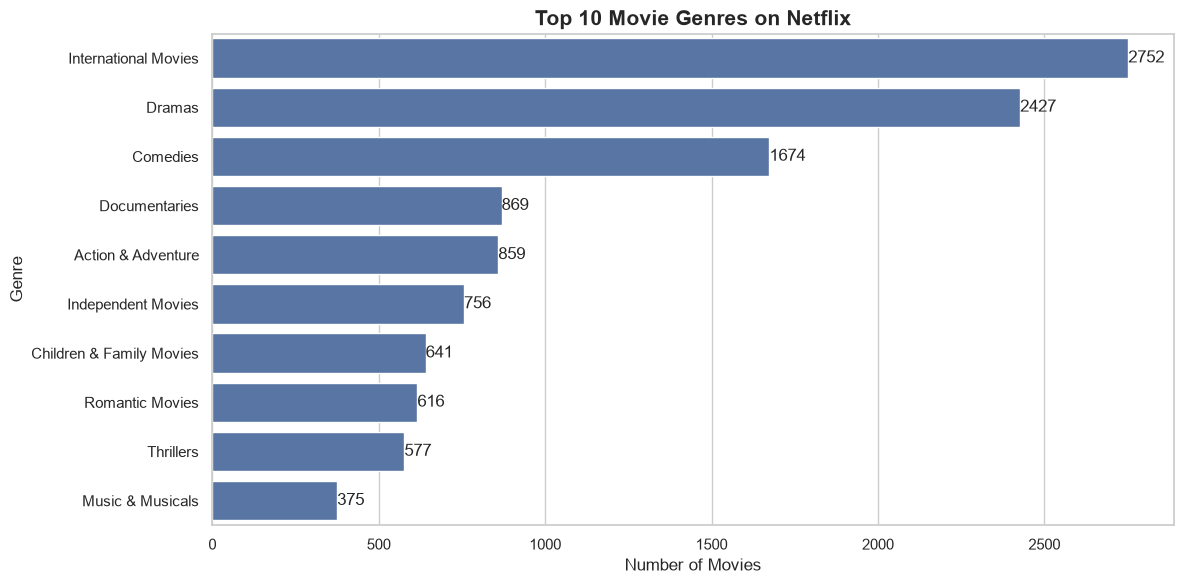

In [420]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=movie_genres,
    x="count",
    y="genre"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Movie Genres on Netflix",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

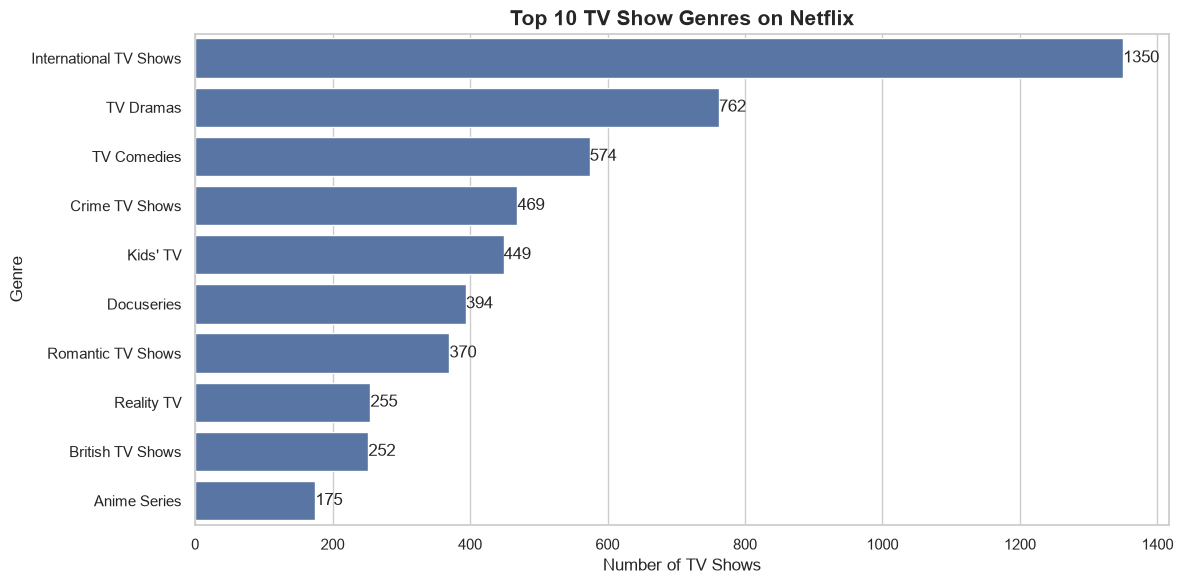

In [421]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=tv_genres,
    x="count",
    y="genre"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 TV Show Genres on Netflix",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of TV Shows")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

### Why This Analysis Matters

Genre analysis by content type helps identify differences in the composition of Netflix's Movie and TV Show catalogs.

### Observation

- **International Movies** are the largest Movie genre category with **2,752 titles**.
- **Dramas (2,427)** and **Comedies (1,674)** are also strongly represented within Movies.
- For TV Shows, **International TV Shows** dominate with **1,350 titles**.
- **TV Dramas (762)** and **TV Comedies (574)** are the next largest TV Show categories.
- Crime TV Shows, Kids' TV, Docuseries, Reality TV, and Anime Series contribute to the diversity of episodic content.
- International content represents the largest genre category in both Movies and TV Shows.

### Key Finding

International content dominates both content formats, while Drama and Comedy categories also represent major portions of Netflix's catalog.

### Business Insight

The strong representation of international content indicates a globally diversified catalog strategy. Movies show strong concentration in Drama, Comedy, and Documentary categories, while TV Shows include a broader mix of episodic formats such as Crime, Reality, Kids' TV, and Anime.

### Recommendation

Netflix should continue maintaining a geographically diverse content portfolio while evaluating genre performance separately for Movies and TV Shows. Viewer engagement data should be used to identify high-growth genres and potential content gaps within each format.

## 10.20 Content Growth Rate Analysis

This analysis evaluates the year-over-year percentage change in the number of titles added to Netflix to identify periods of catalog expansion and decline.

In [422]:
yearly_growth = (
    df_clean["year_added"]
    .value_counts()
    .sort_index()
    .rename("content_count")
    .to_frame()
)

yearly_growth["growth_rate"] = (
    yearly_growth["content_count"]
    .pct_change() * 100
)

yearly_growth

,content_count,growth_rate
year_added,,
2008,2,NaN
2009,2,0.000000
2010,1,-50.000000
2011,13,1200.000000
2012,3,-76.923077
2013,11,266.666667
2014,24,118.181818
2015,82,241.666667
2016,427,420.731707


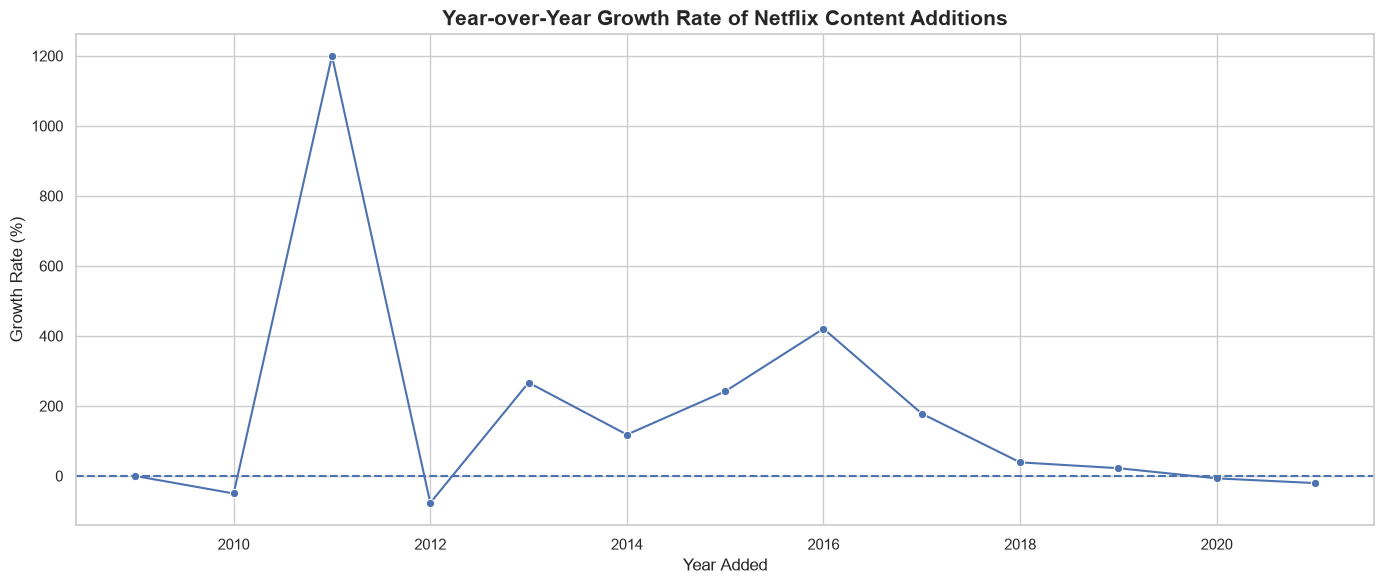

In [423]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    x=yearly_growth.index,
    y=yearly_growth["growth_rate"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Year-over-Year Growth Rate of Netflix Content Additions",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Year Added")
plt.ylabel("Growth Rate (%)")

plt.tight_layout()
plt.show()

### Why This Analysis Matters

Year-over-year growth analysis helps identify periods of rapid catalog expansion and decline in Netflix content additions.

### Observation

- The early years show extremely high and volatile growth rates because the number of content additions was initially very small.
- Content additions increased by approximately **420.73% in 2016** and **177.99% in 2017**.
- Growth remained positive in **2018 (38.92%)** and **2019 (22.26%)**.
- Netflix reached its highest annual content addition count in **2019 with 2,016 titles**.
- The growth rate became negative in **2020 (-6.80%)** and declined further in **2021 (-20.28%)**.

### Key Finding

Netflix's catalog additions experienced rapid expansion between 2015 and 2019, followed by a decline in annual additions during 2020 and 2021.

### Business Insight

The data indicates a shift from rapid catalog expansion to lower annual content additions after 2019. However, this dataset alone cannot determine whether the decline resulted from strategic changes, production disruptions, licensing decisions, or incomplete data coverage.

### Recommendation

Netflix should evaluate content acquisition efficiency and title performance alongside annual addition trends. Future analysis should incorporate watch time, production costs, licensing expenses, and subscriber engagement to determine whether lower catalog growth reflects improved content selectivity or operational constraints.

# 11. Statistical Analysis

This section applies statistical methods to evaluate central tendency, variability, distribution shape, quartile structure, outliers, and numerical relationships within the Netflix catalog.

Movie duration and TV Show season counts are analyzed separately because they use different units of measurement.

## 11.1 Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset and help evaluate the central values, spread, and range of key numerical variables.

In [424]:
catalog_statistics = df_clean[
    ["release_year", "year_added"]
].describe().T

catalog_statistics

,count,mean,std,min,25%,50%,75%,max
release_year,8794.0,2014.183534,8.823527,1925.0,2013.0,2017.0,2019.0,2021.0
year_added,8794.0,2018.872754,1.573789,2008.0,2018.0,2019.0,2020.0,2021.0


In [425]:
movie_statistics = movies["duration_value"].describe()

tv_statistics = tv_shows["duration_value"].describe()

duration_statistics = pd.DataFrame({
    "Movie Duration (Minutes)": movie_statistics,
    "TV Show Seasons": tv_statistics
})

duration_statistics

,Movie Duration (Minutes),TV Show Seasons
count,6128.000000,2666.000000
mean,99.577187,1.751313
std,28.290593,1.550176
min,3.000000,1.000000
25%,87.000000,1.000000
50%,98.000000,1.000000
75%,114.000000,2.000000
max,312.000000,17.000000


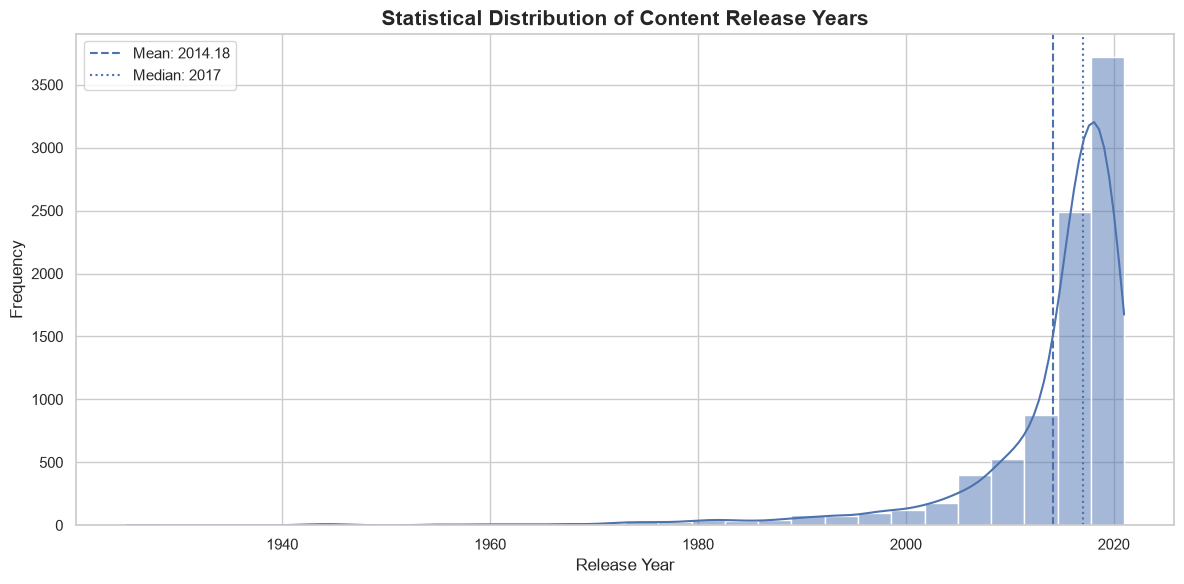

In [426]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df_clean["release_year"],
    bins=30,
    kde=True
)

plt.axvline(
    df_clean["release_year"].mean(),
    linestyle="--",
    label=f'Mean: {df_clean["release_year"].mean():.2f}'
)

plt.axvline(
    df_clean["release_year"].median(),
    linestyle=":",
    label=f'Median: {df_clean["release_year"].median():.0f}'
)

plt.title(
    "Statistical Distribution of Content Release Years",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

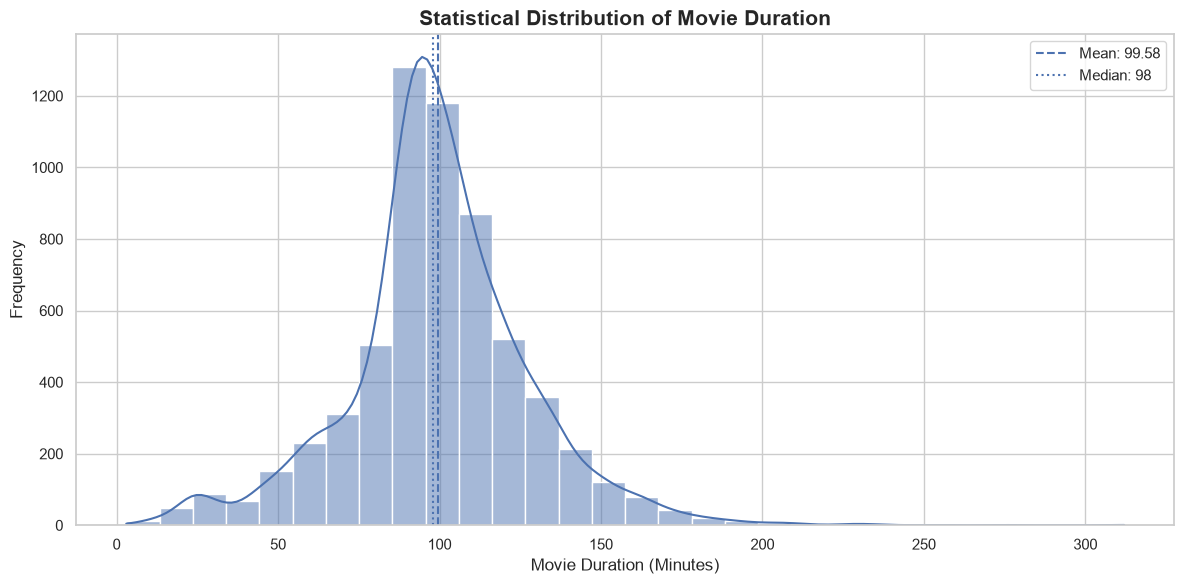

In [427]:
plt.figure(figsize=(12, 6))

sns.histplot(
    movies["duration_value"],
    bins=30,
    kde=True
)

plt.axvline(
    movies["duration_value"].mean(),
    linestyle="--",
    label=f'Mean: {movies["duration_value"].mean():.2f}'
)

plt.axvline(
    movies["duration_value"].median(),
    linestyle=":",
    label=f'Median: {movies["duration_value"].median():.0f}'
)

plt.title(
    "Statistical Distribution of Movie Duration",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Movie Duration (Minutes)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

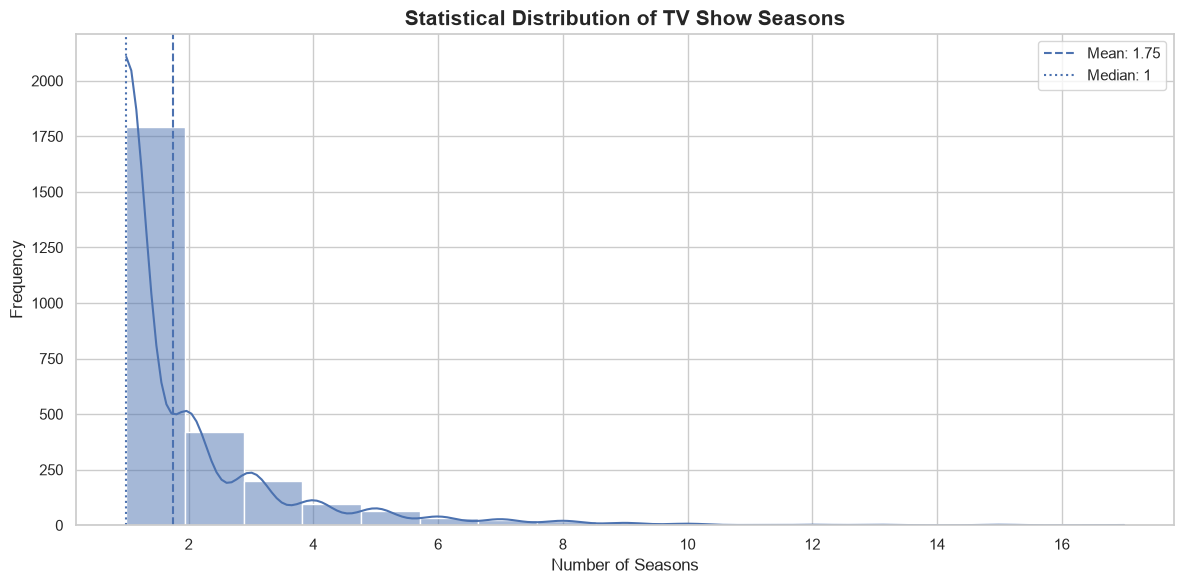

In [428]:
plt.figure(figsize=(12, 6))

sns.histplot(
    tv_shows["duration_value"],
    bins=17,
    kde=True
)

plt.axvline(
    tv_shows["duration_value"].mean(),
    linestyle="--",
    label=f'Mean: {tv_shows["duration_value"].mean():.2f}'
)

plt.axvline(
    tv_shows["duration_value"].median(),
    linestyle=":",
    label=f'Median: {tv_shows["duration_value"].median():.0f}'
)

plt.title(
    "Statistical Distribution of TV Show Seasons",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Seasons")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

### Statistical Interpretation

- The dataset contains **8,794 titles** with valid release year and Netflix addition year information.
- The average content release year is approximately **2014**, while the median is **2017**.
- The difference between the mean and median indicates that older titles extend the release-year distribution toward earlier years.
- The average Netflix addition year is approximately **2019**, with the middle 50% of titles added between **2018 and 2020**.
- Movie durations have an average of **99.58 minutes** and a median of **98 minutes**.
- The close Movie mean and median indicate a relatively balanced central distribution.
- Movie duration has a standard deviation of **28.29 minutes** and ranges from **3 to 312 minutes**.
- TV Shows have an average of **1.75 seasons**, while the median is **1 season**.
- The middle 50% of TV Shows contain between **1 and 2 seasons**.
- TV Show season counts range from **1 to 17 seasons**, indicating the presence of a smaller number of long-running series.

### Key Statistical Finding

Netflix's catalog is concentrated around relatively recent release years. Movie durations are centered close to **100 minutes**, while the TV Show catalog is strongly concentrated around **single-season and short-running series**.

### Analytical Note

Movie duration and TV Show season counts were analyzed separately because they represent different units of measurement and should not be combined into a single duration statistic.

## 11.2 Central Tendency Analysis

Central tendency analysis compares the mean, median, and mode of key numerical variables to identify the typical values and evaluate differences in their central distributions.

In [429]:
central_tendency = pd.DataFrame({
    "Mean": [
        df_clean["release_year"].mean(),
        df_clean["year_added"].mean(),
        movies["duration_value"].mean(),
        tv_shows["duration_value"].mean()
    ],
    "Median": [
        df_clean["release_year"].median(),
        df_clean["year_added"].median(),
        movies["duration_value"].median(),
        tv_shows["duration_value"].median()
    ],
    "Mode": [
        df_clean["release_year"].mode()[0],
        df_clean["year_added"].mode()[0],
        movies["duration_value"].mode()[0],
        tv_shows["duration_value"].mode()[0]
    ]
}, index=[
    "Release Year",
    "Year Added",
    "Movie Duration",
    "TV Show Seasons"
])

central_tendency

,Mean,Median,Mode
Release Year,2014.183534,2017.0,2018
Year Added,2018.872754,2019.0,2019
Movie Duration,99.577187,98.0,90
TV Show Seasons,1.751313,1.0,1


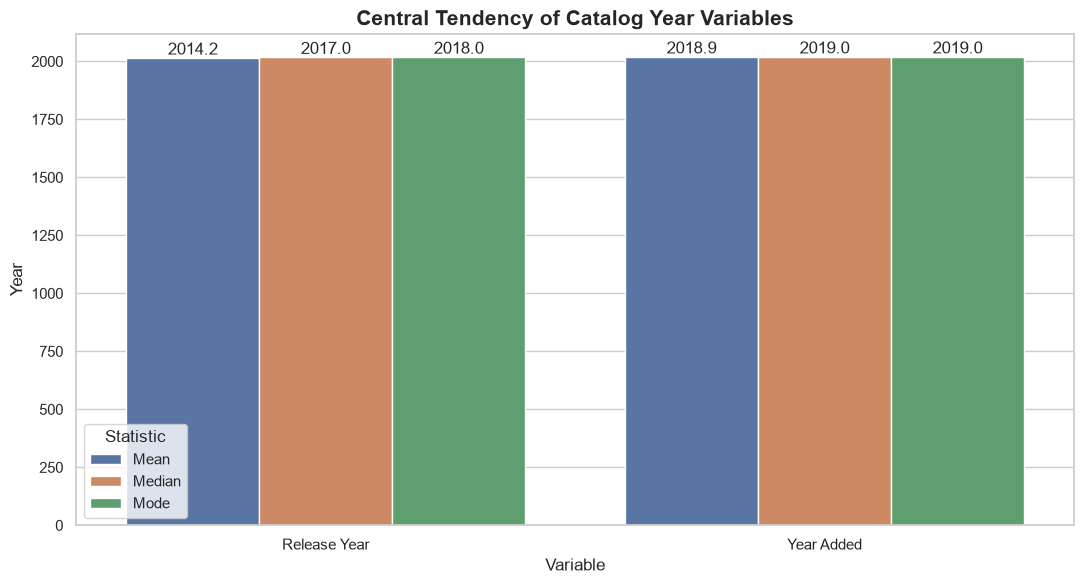

In [430]:
catalog_central = central_tendency.loc[
    ["Release Year", "Year Added"]
].reset_index()

catalog_central = catalog_central.melt(
    id_vars="index",
    var_name="Statistic",
    value_name="Value"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=catalog_central,
    x="index",
    y="Value",
    hue="Statistic"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title(
    "Central Tendency of Catalog Year Variables",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Variable")
plt.ylabel("Year")
plt.legend(title="Statistic")

plt.tight_layout()
plt.show()

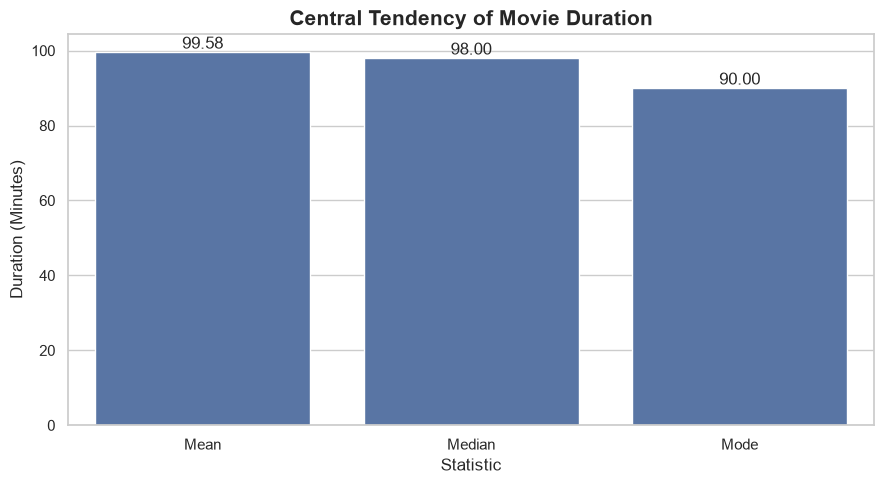

In [431]:
movie_central = central_tendency.loc[
    "Movie Duration"
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=movie_central.index,
    y=movie_central.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title(
    "Central Tendency of Movie Duration",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Statistic")
plt.ylabel("Duration (Minutes)")

plt.tight_layout()
plt.show()

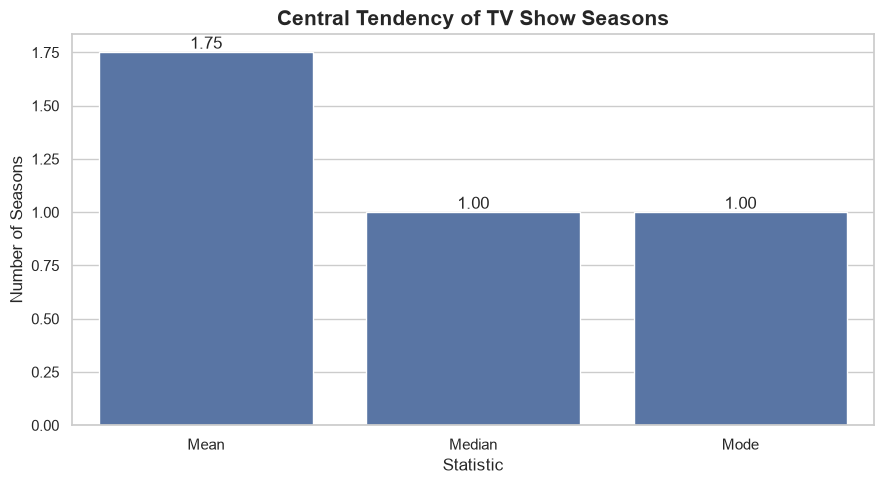

In [432]:
tv_central = central_tendency.loc[
    "TV Show Seasons"
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tv_central.index,
    y=tv_central.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title(
    "Central Tendency of TV Show Seasons",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Statistic")
plt.ylabel("Number of Seasons")

plt.tight_layout()
plt.show()

### Statistical Interpretation

- The mean release year is approximately **2014**, while the median is **2017** and the mode is **2018**.
- The lower mean relative to the median and mode indicates that older titles pull the average release year downward.
- The mean Netflix addition year is approximately **2019**, while both the median and mode are **2019**, indicating strong concentration around this period.
- Movie duration has a mean of **99.58 minutes**, a median of **98 minutes**, and a mode of **90 minutes**.
- The relatively small difference between these measures indicates that the central movie runtime distribution is comparatively balanced.
- TV Shows have a mean of **1.75 seasons**, while both the median and mode are **1 season**.
- The higher mean indicates that a smaller number of multi-season TV Shows increase the average season count.

### Key Statistical Finding

Movie durations show relatively similar measures of central tendency, while TV Show season counts show a clear difference between the mean and median due to multi-season series.

### Business Interpretation

The catalog is strongly concentrated around recent release and addition years. Standard movie runtimes dominate the central distribution, while the TV Show catalog contains a large concentration of single-season content.

### Analytical Note

Central tendency measures were visualized separately for variables with different units and scales to prevent misleading comparisons.

## 11.3 Dispersion and Variability Analysis

Dispersion analysis measures how widely numerical values are distributed around their central values. Standard deviation, variance, range, and coefficient of variation are used to compare variability across key numerical variables.

In [433]:
dispersion_analysis = pd.DataFrame({
    "Standard Deviation": [
        df_clean["release_year"].std(),
        df_clean["year_added"].std(),
        movies["duration_value"].std(),
        tv_shows["duration_value"].std()
    ],
    "Variance": [
        df_clean["release_year"].var(),
        df_clean["year_added"].var(),
        movies["duration_value"].var(),
        tv_shows["duration_value"].var()
    ],
    "Range": [
        df_clean["release_year"].max() - df_clean["release_year"].min(),
        df_clean["year_added"].max() - df_clean["year_added"].min(),
        movies["duration_value"].max() - movies["duration_value"].min(),
        tv_shows["duration_value"].max() - tv_shows["duration_value"].min()
    ],
    "Coefficient of Variation (%)": [
        df_clean["release_year"].std() / df_clean["release_year"].mean() * 100,
        df_clean["year_added"].std() / df_clean["year_added"].mean() * 100,
        movies["duration_value"].std() / movies["duration_value"].mean() * 100,
        tv_shows["duration_value"].std() / tv_shows["duration_value"].mean() * 100
    ]
}, index=[
    "Release Year",
    "Year Added",
    "Movie Duration",
    "TV Show Seasons"
])

dispersion_analysis.round(2)

,Standard Deviation,Variance,Range,Coefficient of Variation (%)
Release Year,8.82,77.85,96,0.44
Year Added,1.57,2.48,13,0.08
Movie Duration,28.29,800.36,309,28.41
TV Show Seasons,1.55,2.40,16,88.52


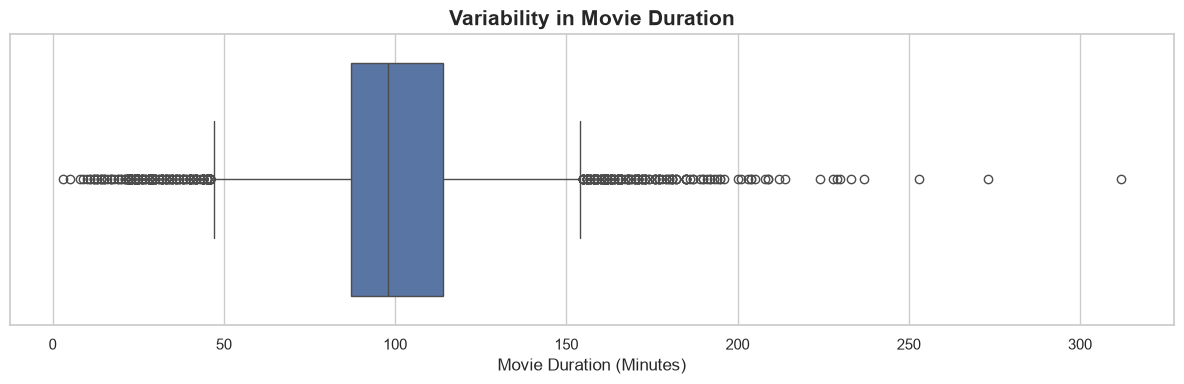

In [434]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=movies["duration_value"]
)

plt.title(
    "Variability in Movie Duration",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Movie Duration (Minutes)")

plt.tight_layout()
plt.show()

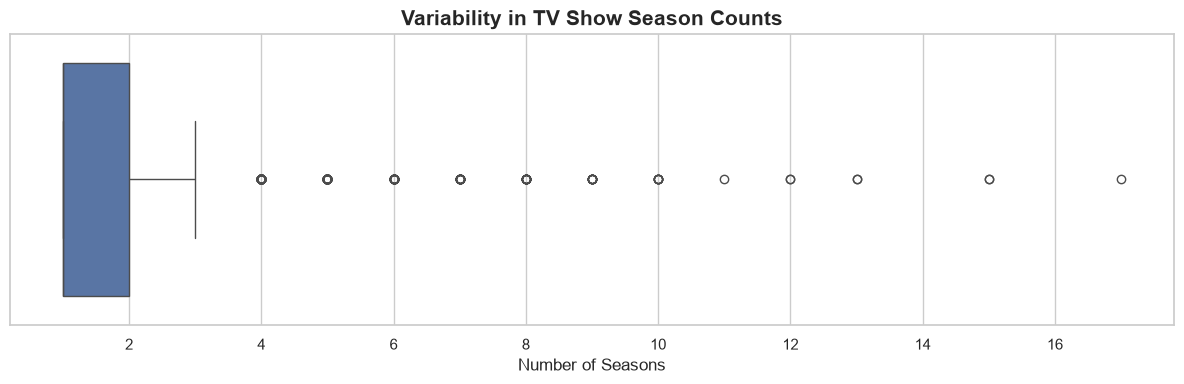

In [435]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=tv_shows["duration_value"]
)

plt.title(
    "Variability in TV Show Season Counts",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Seasons")

plt.tight_layout()
plt.show()

### Statistical Interpretation

- Release year has a standard deviation of **8.82 years** and a range of **96 years**, indicating substantial historical diversity in the catalog.
- Netflix addition year has a standard deviation of only **1.57 years**, showing that content additions are strongly concentrated within a relatively short period.
- Movie duration has a standard deviation of **28.29 minutes** and a variance of **800.36**, indicating noticeable runtime variability.
- Movie durations span a range of **309 minutes**, reflecting the presence of extremely short and extended-length titles.
- TV Show season counts have a standard deviation of **1.55 seasons** and a range of **16 seasons**.
- The coefficient of variation for Movie duration is approximately **28.41%**, indicating moderate relative variability.
- TV Show seasons have a coefficient of variation of approximately **88.52%**, indicating high relative variability in season counts.

### Key Statistical Finding

TV Show season counts show substantially greater relative variability than Movie durations, while Netflix addition years are tightly concentrated around recent years.

### Business Interpretation

The Movie catalog maintains a relatively consistent central runtime while still supporting diverse content lengths. TV Shows show greater relative variation because the catalog contains a large concentration of single-season titles alongside a smaller number of long-running series.

### Analytical Note

The coefficient of variation for calendar-year variables should not be directly compared with duration-based variables because calendar years use an arbitrary numerical origin. Standard deviation and range provide more meaningful measures for interpreting year-based variability.

## 11.4 Skewness and Distribution Analysis

Skewness analysis evaluates the asymmetry of numerical distributions and helps determine whether values are balanced or concentrated toward one side of the distribution.

In [436]:
skewness_analysis = pd.DataFrame({
    "Skewness": [
        df_clean["release_year"].skew(),
        df_clean["year_added"].skew(),
        movies["duration_value"].skew(),
        tv_shows["duration_value"].skew()
    ]
}, index=[
    "Release Year",
    "Year Added",
    "Movie Duration",
    "TV Show Seasons"
])

skewness_analysis.round(3)

,Skewness
Release Year,-3.447
Year Added,-0.706
Movie Duration,0.203
TV Show Seasons,3.395


In [437]:
def classify_skewness(value):
    if value < -1:
        return "Highly Negatively Skewed"
    elif value < -0.5:
        return "Moderately Negatively Skewed"
    elif value <= 0.5:
        return "Approximately Symmetric"
    elif value <= 1:
        return "Moderately Positively Skewed"
    else:
        return "Highly Positively Skewed"


skewness_analysis["Distribution Shape"] = (
    skewness_analysis["Skewness"]
    .apply(classify_skewness)
)

skewness_analysis.round(3)

,Skewness,Distribution Shape
Release Year,-3.447,Highly Negatively Skewed
Year Added,-0.706,Moderately Negatively Skewed
Movie Duration,0.203,Approximately Symmetric
TV Show Seasons,3.395,Highly Positively Skewed


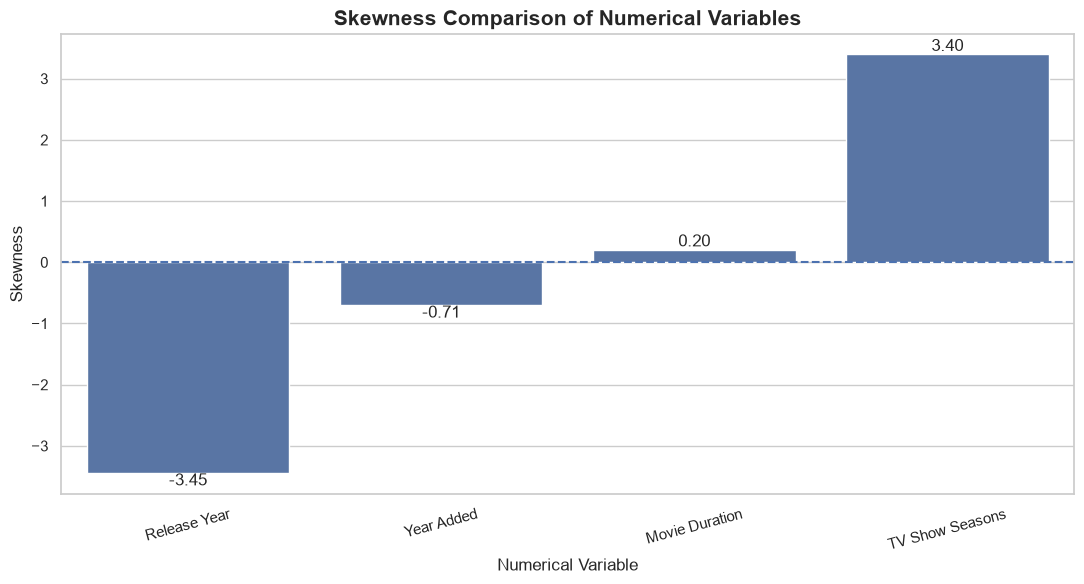

In [438]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=skewness_analysis.index,
    y=skewness_analysis["Skewness"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title(
    "Skewness Comparison of Numerical Variables",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Numerical Variable")
plt.ylabel("Skewness")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Statistical Interpretation

- Release year has a skewness value of **-3.447**, indicating a highly negatively skewed distribution.
- The strong negative skew shows that the catalog is concentrated around recent release years, while older titles create a long left tail.
- Year added has a skewness value of **-0.706**, indicating a moderately negatively skewed distribution.
- This suggests that Netflix content additions are concentrated in later years, with fewer titles added during the platform's earlier catalog years.
- Movie duration has a skewness value of **0.203**, indicating an approximately symmetric distribution.
- This result is consistent with the relatively close Movie duration mean (**99.58 minutes**) and median (**98 minutes**).
- TV Show season counts have a skewness value of **3.395**, indicating a highly positively skewed distribution.
- Most TV Shows contain a small number of seasons, while a limited number of long-running series create a long right tail.

### Key Statistical Finding

Release years are strongly left-skewed toward recent content, while TV Show season counts are strongly right-skewed due to a small number of long-running series. Movie durations show the most balanced distribution among the analyzed variables.

### Business Interpretation

The release-year distribution indicates a catalog strongly concentrated around relatively recent titles while still maintaining older content. The strong positive skew in TV Show seasons reflects a catalog structure dominated by short-running series with comparatively few long-running shows.

### Analytical Note

Skewness describes the shape and asymmetry of a distribution. It does not directly measure content quality, popularity, or viewer preference.

## 11.5 Quartile and IQR Analysis

Quartile analysis evaluates the central 50% of numerical distributions. The Interquartile Range (IQR) measures the spread between the first and third quartiles and provides a robust measure of variability that is less affected by extreme values.

In [439]:
quartile_analysis = pd.DataFrame({
    "Q1": [
        df_clean["release_year"].quantile(0.25),
        df_clean["year_added"].quantile(0.25),
        movies["duration_value"].quantile(0.25),
        tv_shows["duration_value"].quantile(0.25)
    ],
    "Median": [
        df_clean["release_year"].median(),
        df_clean["year_added"].median(),
        movies["duration_value"].median(),
        tv_shows["duration_value"].median()
    ],
    "Q3": [
        df_clean["release_year"].quantile(0.75),
        df_clean["year_added"].quantile(0.75),
        movies["duration_value"].quantile(0.75),
        tv_shows["duration_value"].quantile(0.75)
    ]
}, index=[
    "Release Year",
    "Year Added",
    "Movie Duration",
    "TV Show Seasons"
])

quartile_analysis["IQR"] = (
    quartile_analysis["Q3"] - quartile_analysis["Q1"]
)

quartile_analysis

,Q1,Median,Q3,IQR
Release Year,2013.0,2017.0,2019.0,6.0
Year Added,2018.0,2019.0,2020.0,2.0
Movie Duration,87.0,98.0,114.0,27.0
TV Show Seasons,1.0,1.0,2.0,1.0


### Statistical Interpretation

- The middle 50% of content release years fall between **2013 and 2019**, producing an IQR of **6 years**.
- The median release year is **2017**, confirming that the catalog is strongly concentrated around relatively recent content.
- The middle 50% of Netflix content additions occurred between **2018 and 2020**, with an IQR of only **2 years**.
- Movie durations have a first quartile of **87 minutes** and a third quartile of **114 minutes**.
- The middle 50% of Movies therefore fall within a **27-minute runtime range**, centered around a median duration of **98 minutes**.
- TV Shows have a first quartile of **1 season**, a median of **1 season**, and a third quartile of **2 seasons**.
- The TV Show season IQR is only **1 season**, showing that the central portion of the catalog is highly concentrated around short-running series.

### Key Statistical Finding

The central 50% of Netflix content is concentrated around recent release and addition years. Movie runtimes show a relatively defined central range of **87–114 minutes**, while most TV Shows are concentrated between **1 and 2 seasons**.

### Business Interpretation

The quartile structure indicates a catalog centered around recent content, conventional movie runtimes, and short-running TV series. Extreme values exist outside these central ranges but do not represent the typical catalog structure.

### Analytical Note

The IQR provides a robust measure of spread because it focuses on the middle 50% of observations and is less influenced by extreme values than the full range.

## 11.6 Outlier Statistical Summary

This analysis applies the IQR method to numerical variables to summarize potential statistical outliers and compare their relative frequency across the Netflix catalog.

In [440]:
def calculate_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return pd.Series({
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(series) * 100
    })

In [441]:
outlier_summary = pd.DataFrame({
    "Release Year": calculate_outliers(
        df_clean["release_year"]
    ),
    "Year Added": calculate_outliers(
        df_clean["year_added"]
    ),
    "Movie Duration": calculate_outliers(
        movies["duration_value"]
    ),
    "TV Show Seasons": calculate_outliers(
        tv_shows["duration_value"]
    )
}).T

outlier_summary.round(2)

,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
Release Year,2004.0,2028.0,717.0,8.15
Year Added,2015.0,2023.0,56.0,0.64
Movie Duration,46.5,154.5,450.0,7.34
TV Show Seasons,-0.5,3.5,254.0,9.53


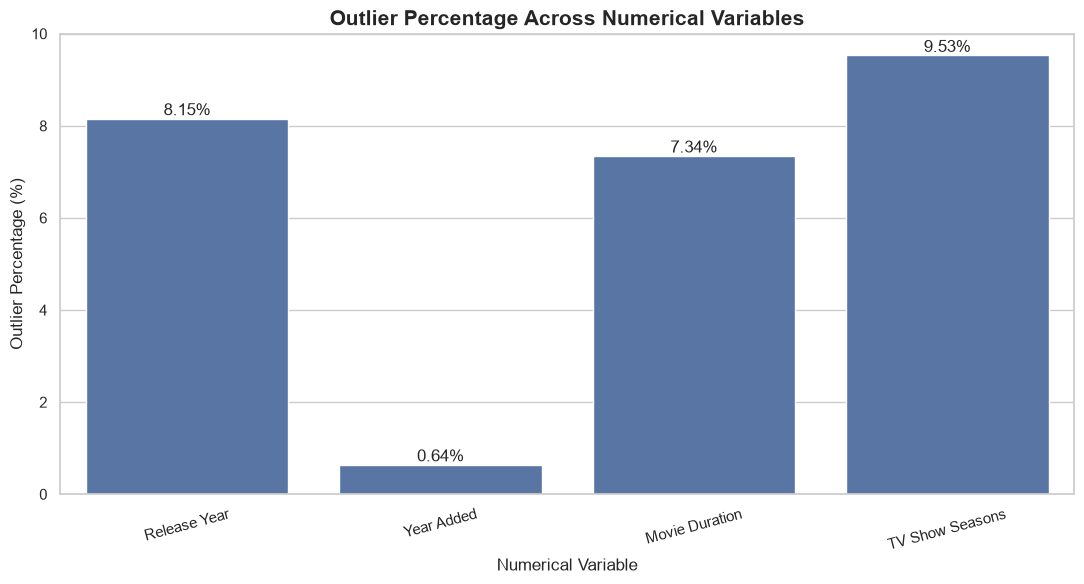

In [442]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=outlier_summary.index,
    y=outlier_summary["Outlier Percentage"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title(
    "Outlier Percentage Across Numerical Variables",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Numerical Variable")
plt.ylabel("Outlier Percentage (%)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Statistical Interpretation

- Release year contains **717 potential outliers**, representing approximately **8.15%** of the analyzed titles.
- Using the IQR method, release years below **2004** are statistically classified as outliers.
- Year added contains only **56 potential outliers (0.64%)**, indicating strong concentration within the main catalog addition period.
- Movie duration contains **450 potential outliers (7.34%)**, with durations below **46.5 minutes** or above **154.5 minutes**.
- TV Show season counts contain **254 potential outliers (9.53%)**.
- TV Shows with more than **3.5 seasons** are statistically identified as outliers under the IQR method.
- TV Show seasons have the highest outlier percentage among the analyzed numerical variables.

### Key Statistical Finding

TV Show season counts show the highest relative outlier frequency at **9.53%**, followed by release year at **8.15%** and Movie duration at **7.34%**. Year added contains comparatively few statistical outliers.

### Business Interpretation

The outlier structure reflects catalog diversity rather than automatically indicating poor data quality. Older titles, unusually short or long Movies, and long-running TV Shows may represent valid content segments with distinct catalog value.

### Analytical Decision

Statistical outliers were not automatically removed. Outlier status was treated as an investigation signal because extreme observations may represent valid titles rather than data errors.

### Analytical Note

IQR-based outlier detection identifies values that are unusual relative to the distribution. It does not independently determine whether an observation is incorrect.

## 11.7 Correlation Analysis

Correlation analysis evaluates the strength and direction of linear relationships between numerical variables. Pearson correlation is used to identify numerical variables that move together within the Netflix catalog.

In [443]:
correlation_data = df_clean[
    [
        "release_year",
        "year_added"
    ]
].copy()

correlation_matrix = correlation_data.corr()

correlation_matrix

,release_year,year_added
release_year,1.000000,0.111548
year_added,0.111548,1.000000


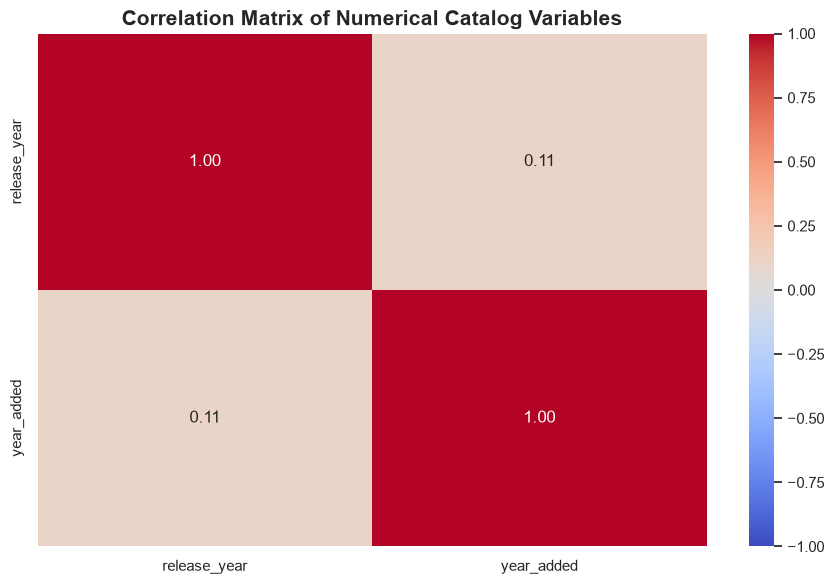

In [444]:
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Correlation Matrix of Numerical Catalog Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [445]:
movie_correlation = movies[
    [
        "release_year",
        "year_added",
        "duration_value"
    ]
].corr()

movie_correlation

,release_year,year_added,duration_value
release_year,1.000000,0.039351,-0.206285
year_added,0.039351,1.000000,0.124436
duration_value,-0.206285,0.124436,1.000000


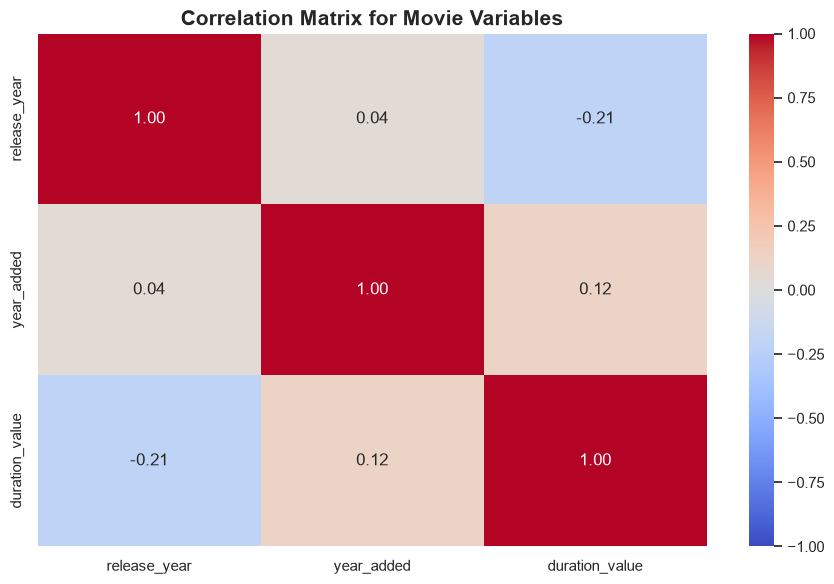

In [446]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    movie_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Correlation Matrix for Movie Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Statistical Interpretation

- Release year and year added show a **very weak positive correlation of 0.112** across the overall Netflix catalog.

- This indicates only a weak linear association between a title's release year and the year it was added to the catalog.
- Within the Movie catalog, release year and year added have an even weaker positive correlation of approximately **0.039**.
- Movie duration and release year show a **weak negative correlation of -0.206**.
- This suggests that newer Movies tend to have slightly shorter runtimes within the dataset, although the relationship is weak.
- Movie duration and year added show a **weak positive correlation of 0.124**.
- No strong linear correlations were identified among the independent numerical Movie variables.

### Key Statistical Finding

The analyzed independent numerical variables show only weak linear relationships. Movie duration is not strongly associated with either release year or Netflix addition year.

### Business Interpretation

The weak correlations indicate that Movie runtime varies across different release and catalog addition periods. Runtime patterns cannot be reliably explained using release year or year added alone.

### Analytical Decision

The engineered `content_age` feature was excluded from the independent correlation matrix because it is mathematically derived from `year_added` and `release_year`. Including it would introduce structural correlation and could create a misleading interpretation.

### Analytical Note

Correlation measures linear association and does not establish causation. Weak correlation also does not rule out non-linear relationships or patterns involving categorical variables.

## 11.8 Statistical Comparison by Content Type

This analysis statistically compares the release timing and content age of Movies and TV Shows to identify differences in their catalog distributions.

In [447]:
content_type_statistics = (
    df_clean
    .groupby("type")
    .agg(
        release_year_mean=("release_year", "mean"),
        release_year_median=("release_year", "median"),
        release_year_std=("release_year", "std"),
        content_age_mean=("content_age", "mean"),
        content_age_median=("content_age", "median"),
        content_age_std=("content_age", "std")
    )
)

content_type_statistics.round(2)

,release_year_mean,release_year_median,release_year_std,content_age_mean,content_age_median,content_age_std
type,,,,,,
Movie,2013.12,2016.0,9.68,5.73,2.0,9.75
TV Show,2016.63,2018.0,5.73,2.31,0.0,5.33


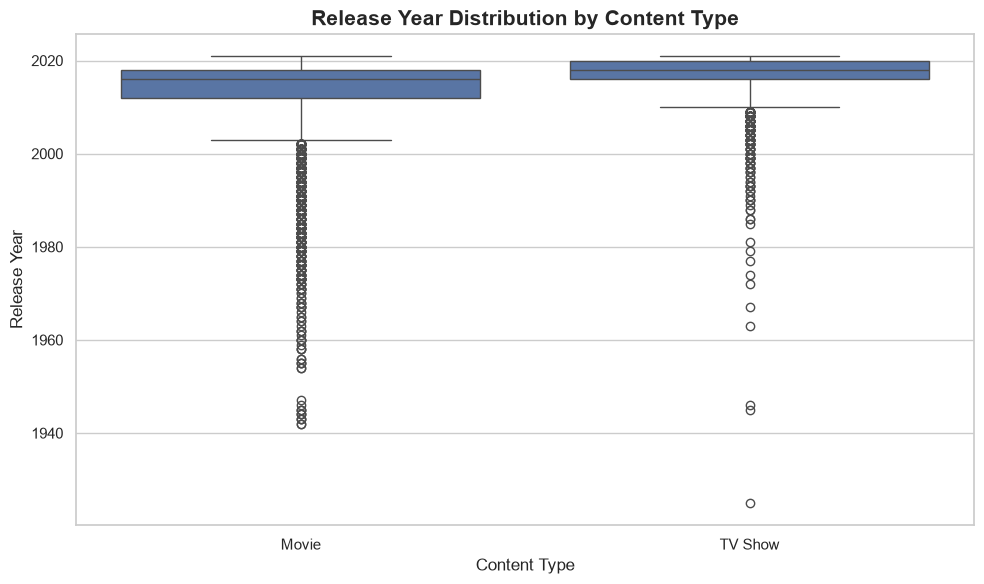

In [448]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="type",
    y="release_year"
)

plt.title(
    "Release Year Distribution by Content Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Type")
plt.ylabel("Release Year")

plt.tight_layout()
plt.show()

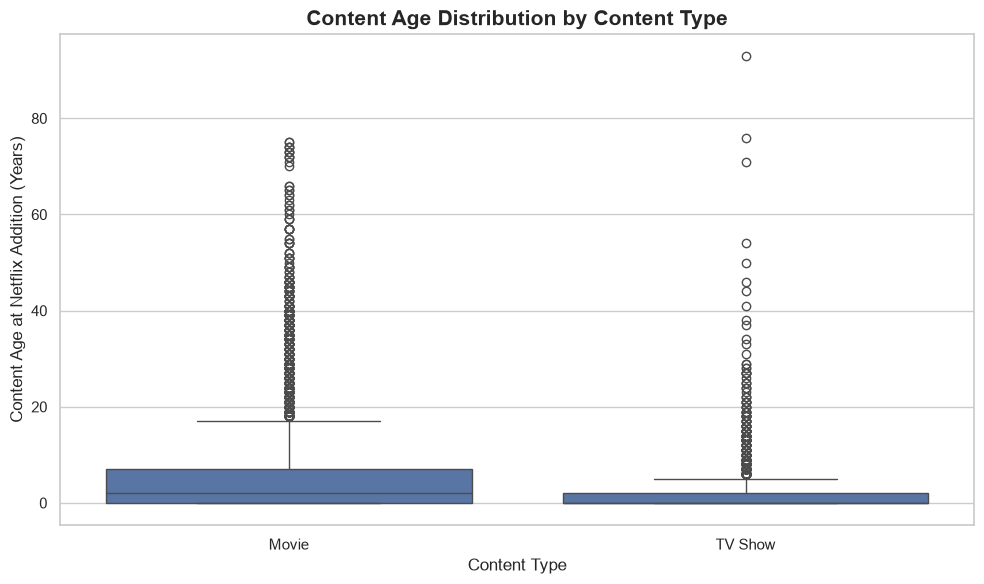

In [449]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="type",
    y="content_age"
)

plt.title(
    "Content Age Distribution by Content Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Type")
plt.ylabel("Content Age at Netflix Addition (Years)")

plt.tight_layout()
plt.show()

### Statistical Interpretation

- Movies have an average release year of approximately **2013**, compared with approximately **2017** for TV Shows.
- The median release year is **2016 for Movies** and **2018 for TV Shows**.
- Movie release years have a standard deviation of **9.68 years**, compared with **5.73 years** for TV Shows.
- This indicates that Movies cover a wider historical release range, while TV Shows are more concentrated around recent years.
- Movies have an average content age of **5.73 years** at the time of Netflix addition, compared with **2.30 years** for TV Shows.
- The median content age is **2 years for Movies** and **0 years for TV Shows**.
- Movie content age has a standard deviation of **9.74 years**, compared with **5.32 years** for TV Shows.
- The zero-year median for TV Shows indicates that at least half of TV Shows were added in the same calendar year as their recorded release year.

### Key Statistical Finding

TV Shows are statistically concentrated around more recent release years and shorter content-age intervals, while Movies show greater historical and content-age variability.

### Business Interpretation

The catalog structure suggests different acquisition patterns for Movies and TV Shows. TV Shows are more concentrated around recent releases, while the Movie catalog includes a broader mix of recent and older titles.

### Analytical Note

These results describe catalog patterns only. The dataset does not contain licensing, production, acquisition, or release-strategy data, so the observed differences should not be interpreted as direct evidence of Netflix's internal strategy.

## 11.9 Statistical Findings and Business Interpretation

This section consolidates the major statistical findings identified across the Netflix catalog analysis.

### Statistical Findings Summary

| Statistical Area | Key Finding | Interpretation |
|---|---|---|
| Release Year | Median release year is 2017 | The catalog is concentrated around relatively recent content |
| Year Added | Median and mode are 2019 | Content additions are strongly concentrated around recent catalog years |
| Movie Duration | Mean 99.58 min and median 98 min | Movie runtimes have a relatively balanced central distribution |
| TV Show Seasons | Mean 1.75 and median 1 season | The catalog is strongly concentrated around short-running TV Shows |
| Movie Variability | CV approximately 28.41% | Movie runtimes show moderate relative variability |
| TV Show Variability | CV approximately 88.52% | Season counts show high relative variability |
| Movie Duration IQR | 87 to 114 minutes | The middle 50% of Movies follow a defined runtime range |
| TV Show Season IQR | 1 to 2 seasons | Most TV Shows are concentrated around short season lifecycles |
| Release Year Skewness | -3.447 | Older titles create a long left tail |
| TV Show Season Skewness | 3.395 | Long-running series create a strong right tail |
| Outlier Analysis | TV Show seasons have 9.53% outliers | Multi-season series represent statistically unusual but potentially valid content |
| Correlation Analysis | Independent numerical correlations are weak | Release timing and Movie duration show limited linear association |
| Content Type Comparison | TV Shows are more recent than Movies | Movies contain greater historical catalog diversity |

### Overall Statistical Conclusion

The statistical analysis demonstrates that the Netflix catalog is concentrated around relatively recent content, with substantial differences between Movies and TV Shows.

Movie durations are centered close to **100 minutes** and show moderate variability with a relatively balanced distribution. In contrast, TV Show season counts are strongly right-skewed and concentrated around **one to two seasons**, while a smaller number of long-running series create substantial relative variability.

Movies show greater historical diversity and higher content age at the time of Netflix addition. TV Shows are concentrated around more recent release years and shorter content-age intervals.

The correlation analysis identified no strong independent linear relationships among release timing, Netflix addition year, and Movie duration. Statistical outliers were retained because unusual values may represent valid catalog segments rather than data quality errors.

### Business Interpretation

The catalog contains distinct structural patterns across content formats. Movie and TV Show strategies should therefore be evaluated separately rather than using a single catalog-wide framework.

Runtime, content age, genre, rating, geographic representation, and content type should be considered together when evaluating catalog composition and identifying potential content gaps.

### Analytical Limitation

The dataset describes catalog metadata and does not include viewer engagement, watch time, subscriber behavior, content cost, licensing information, or revenue. Therefore, the analysis identifies catalog patterns but cannot directly measure content performance or profitability.

# 12. Advanced Visualization

This section presents advanced multivariate visualizations that combine multiple catalog dimensions to identify deeper patterns across content type, release timing, geographic representation, ratings, and content age.

## 12.1 Content Type Trend Over Time

This analysis compares annual Netflix catalog additions for Movies and TV Shows to evaluate how content-type composition changed over time.

In [450]:
content_type_trend = (
    df_clean
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

content_type_trend.head()

,year_added,type,count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13


In [451]:
content_type_trend.tail(10)

,year_added,type,count
14,2017,Movie,838
15,2017,TV Show,349
16,2018,Movie,1237
17,2018,TV Show,412
18,2019,Movie,1424
19,2019,TV Show,592
20,2020,Movie,1284
21,2020,TV Show,595
22,2021,Movie,993
23,2021,TV Show,505


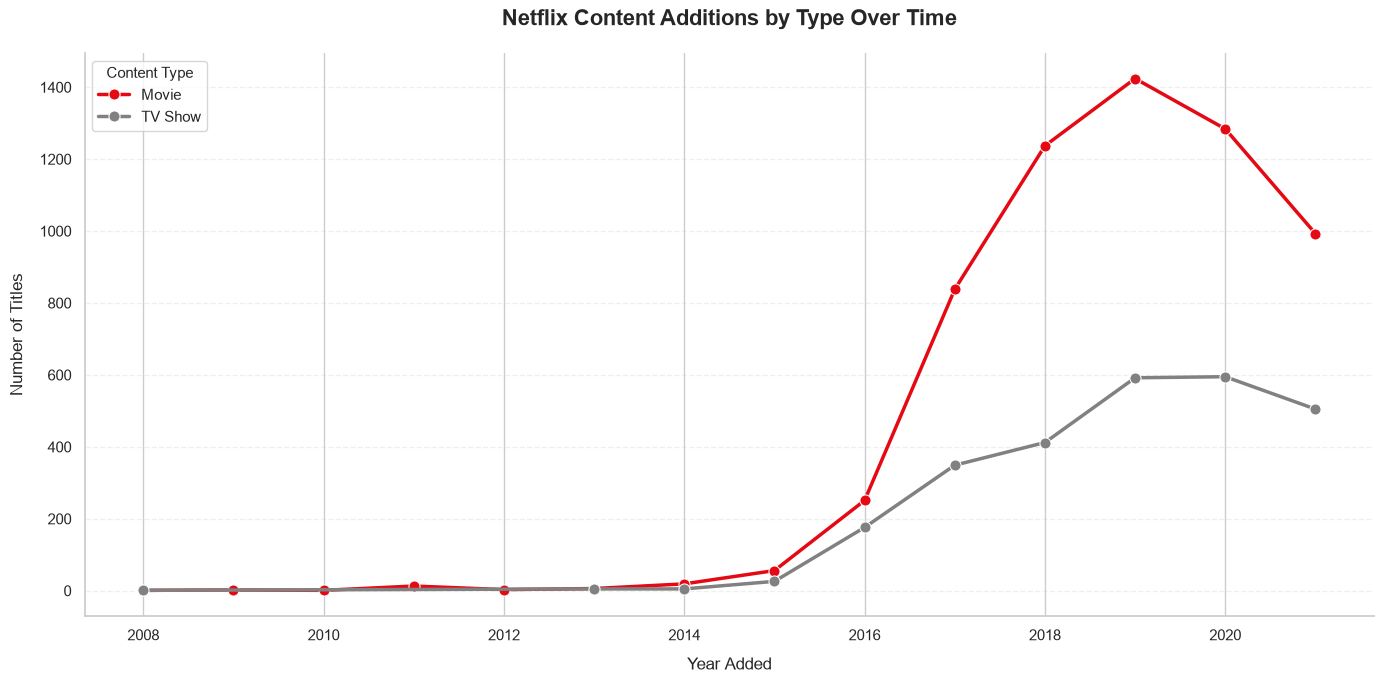

In [452]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot size aur theme background set karna
plt.figure(figsize=(14, 7))

# Custom Premium Colors: Movies ke liye bold Red, TV Shows ke liye Light Gray
# (Aap isko apne purane plots ki color scheme ke hisab se modify bhi kar sakte hain)
custom_colors = {"Movie": "#E50914", "TV Show": "#818181"}

ax = sns.lineplot(
    data=content_type_trend,
    x="year_added",
    y="count",
    hue="type",
    palette=custom_colors,
    marker="o",
    markersize=8,
    linewidth=2.5
)

# Title & Labels custom styling
plt.title(
    "Netflix Content Additions by Type Over Time",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.xlabel("Year Added", fontsize=12, labelpad=10)
plt.ylabel("Number of Titles", fontsize=12, labelpad=10)

# Legend styling
plt.legend(title="Content Type", title_fontsize='11', loc='upper left', frameon=True)

# Spines (borders) remove karke modern look dena
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)  # clean background grid

plt.tight_layout()
plt.show()

### Observation

- Movie additions increased from **838 titles in 2017** to **1,237 titles in 2018**.
- Movie additions reached their highest observed level in **2019 with 1,424 titles**.
- Movie additions then declined to **1,284 titles in 2020** and **993 titles in 2021**.
- TV Show additions increased from **349 titles in 2017** to **592 titles in 2019**.
- Unlike Movies, TV Show additions remained relatively stable in **2020 with 595 titles**.
- TV Show additions declined to **505 titles in 2021**.
- Movies consistently received more annual catalog additions than TV Shows throughout the observed period.

### Key Finding

Movies dominated annual Netflix catalog additions, but the gap between Movie and TV Show additions narrowed after 2019 as Movie additions declined more sharply.

### Business Insight

The content-type trend indicates different catalog addition patterns for Movies and TV Shows. Movie additions experienced stronger expansion before 2019 followed by a noticeable decline, while TV Show additions remained comparatively stable during 2019 and 2020.

### Recommendation

Content acquisition trends should be evaluated separately for Movies and TV Shows. Additional performance data such as watch time, completion rate, and acquisition cost would help determine whether the changing content mix reflects differences in audience demand or catalog strategy.

### Analytical Note

The 2021 decline should be interpreted cautiously because dataset coverage may not represent a complete annual period.

## 12.2 Country and Content Type Composition

This analysis compares the composition of Movies and TV Shows across leading content-producing countries to identify geographic differences in Netflix's catalog structure.

In [453]:
country_type_data = (
    df_clean[df_clean["country"] != "Unknown"]
    .assign(country=df_clean["country"].str.split(", "))
    .explode("country")
)

top_countries = (
    country_type_data["country"]
    .value_counts()
    .head(10)
    .index
)

country_type_composition = (
    country_type_data[
        country_type_data["country"].isin(top_countries)
    ]
    .groupby(["country", "type"])
    .size()
    .reset_index(name="count")
)

country_type_composition

,country,type,count
0,Canada,Movie,319
1,Canada,TV Show,126
2,France,Movie,303
3,France,TV Show,90
4,Germany,Movie,182
5,Germany,TV Show,44
6,India,Movie,962
7,India,TV Show,84
8,Japan,Movie,119
9,Japan,TV Show,198


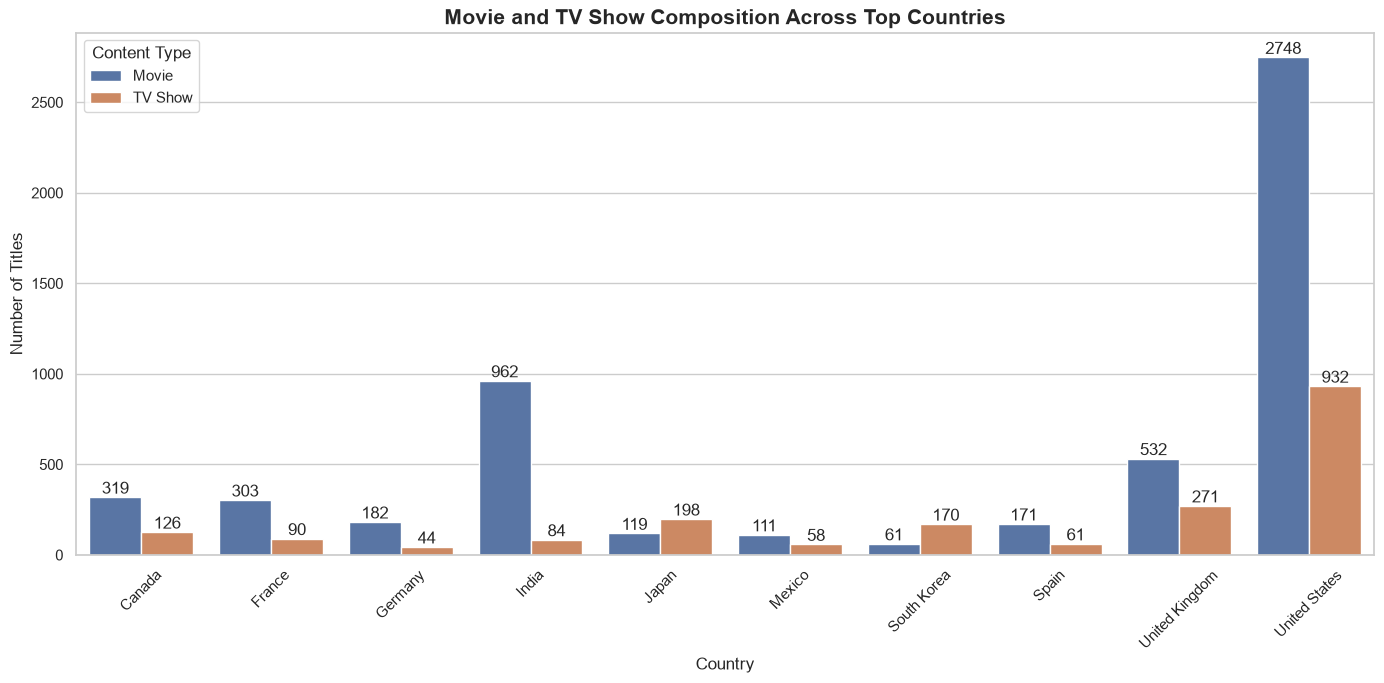

In [454]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=country_type_composition,
    x="country",
    y="count",
    hue="type"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Movie and TV Show Composition Across Top Countries",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()

### Observation

- The United States has the largest catalog representation with **2,748 Movies and 932 TV Shows**.
- India shows a strong Movie concentration with **962 Movies compared with only 84 TV Shows**.
- The United Kingdom contains **532 Movies and 271 TV Shows**, showing a comparatively more balanced content mix.
- Japan is one of the few leading countries where TV Shows (**198**) exceed Movies (**119**).
- South Korea shows an even stronger TV-focused pattern with **170 TV Shows compared with 61 Movies**.
- Canada and France remain Movie-dominant, with **319 and 303 Movies**, respectively.
- Germany, Spain, and Mexico also contain more Movies than TV Shows in the analyzed catalog.

### Key Finding

Content-type composition differs substantially across countries. The United States dominates both formats, India is strongly Movie-oriented, while Japan and South Korea show greater TV Show representation.

### Business Insight

The geographic composition of the catalog is not uniform across content formats. Country-level content analysis should therefore consider both total catalog size and the Movie-to-TV Show mix.

### Recommendation

Catalog planning and geographic content evaluation should use country-specific content-type profiles. Markets with strong TV Show representation, such as Japan and South Korea, should be analyzed separately from Movie-dominant markets such as India.

### Analytical Note

Titles associated with multiple countries were exploded into individual country records. Therefore, a co-produced title may contribute to the count of more than one country.

## 12.3 Rating Composition by Content Type

This analysis compares the percentage composition of content ratings within Movies and TV Shows. Normalized percentages are used so that both content types can be compared fairly despite having different total catalog sizes.

In [455]:
rating_type_percentage = pd.crosstab(
    df_clean["rating"],
    df_clean["type"],
    normalize="columns"
) * 100

rating_type_percentage.round(2)

type,Movie,TV Show
rating,,
G,0.67,0.00
NC-17,0.05,0.00
NR,1.22,0.15
PG,4.68,0.00
PG-13,8.00,0.00
R,13.01,0.08
TV-14,23.29,27.38
TV-G,2.06,3.53
TV-MA,33.68,42.95


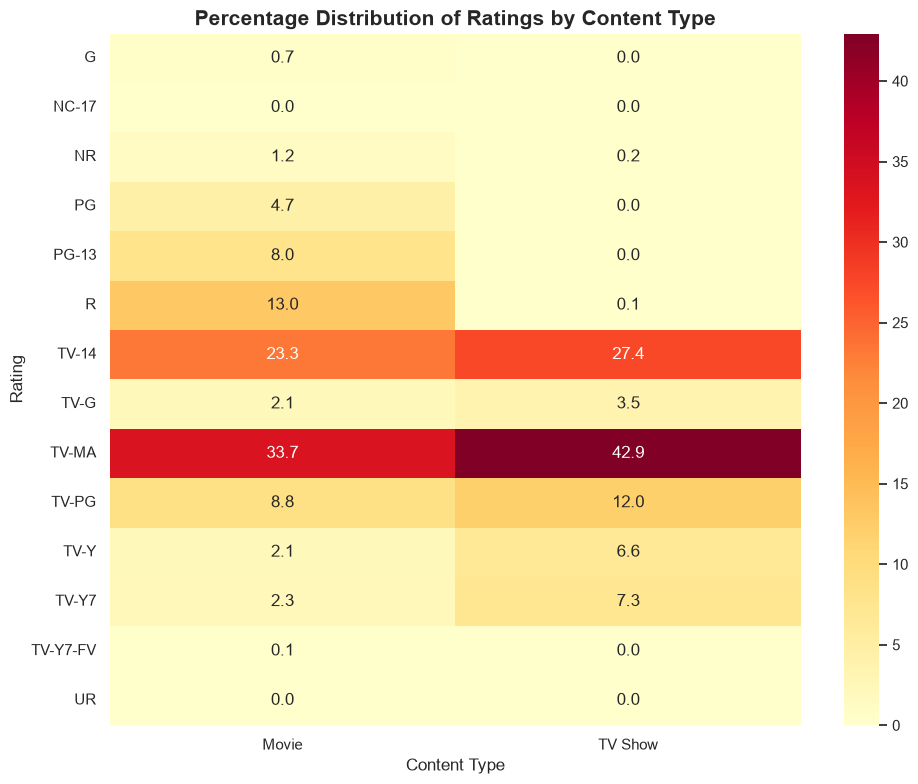

In [456]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_type_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title(
    "Percentage Distribution of Ratings by Content Type",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [457]:
dominant_rating_by_type = rating_type_percentage.idxmax()

dominant_rating_by_type

type
Movie      TV-MA
TV Show    TV-MA
dtype: str

### Observation

- **TV-MA is the dominant rating for both content types**, representing **33.68% of Movies** and **42.95% of TV Shows**.
- TV-14 represents **23.29% of Movies** and **27.38% of TV Shows**.
- R-rated content accounts for **13.01% of Movies** but only **0.08% of TV Shows**.
- PG-13 represents **8.00% of Movies**, while no TV Shows are classified under this rating in the analyzed dataset.
- TV-PG accounts for **8.81% of Movies** and **12.04% of TV Shows**.
- Children's ratings are proportionally more represented among TV Shows. TV-Y accounts for **6.56%** and TV-Y7 for **7.28% of TV Shows**, compared with **2.14% and 2.27% of Movies**, respectively.
- G, PG, and PG-13 ratings are primarily associated with Movies in the catalog.

### Key Finding

Mature-audience ratings dominate both Movies and TV Shows, with TV-MA showing an especially strong concentration among TV Shows. Rating composition also differs noticeably between content formats.

### Business Insight

The catalog has a strong mature-content concentration, while TV Shows contain a comparatively larger share of children's TV ratings. Movies show greater representation across theatrical rating categories such as R, PG-13, and PG.

### Recommendation

Rating composition should be evaluated by content type rather than using catalog-wide totals alone. Additional viewer demographic and engagement data would help assess whether the current rating mix aligns with audience demand.

### Analytical Note

Percentages were normalized independently within Movies and TV Shows. Therefore, the analysis compares rating composition rather than absolute title counts.

## 12.4 Genre and Content Age Analysis

This analysis compares the average content age across genres to identify which genre categories contain relatively newer or older content at the time of Netflix addition.

Genres with fewer than 100 titles are excluded to reduce the influence of small sample sizes and improve the reliability of genre-level comparisons.

In [458]:
genre_age_data = (
    df_clean
    .assign(genre=df_clean["listed_in"].str.split(", "))
    .explode("genre")
)

genre_age_summary = (
    genre_age_data
    .groupby("genre")
    .agg(
        title_count=("title", "count"),
        average_content_age=("content_age", "mean"),
        median_content_age=("content_age", "median")
    )
    .reset_index()
)

genre_age_summary.head()

,genre,title_count,average_content_age,median_content_age
0,Action & Adventure,859,9.622378,4.0
1,Anime Features,71,8.140845,4.0
2,Anime Series,175,4.171429,1.0
3,British TV Shows,252,2.583333,1.0
4,Children & Family Movies,641,5.204368,1.0


In [459]:
genre_age_filtered = (
    genre_age_summary[
        genre_age_summary["title_count"] >= 100
    ]
    .sort_values(
        "average_content_age",
        ascending=False
    )
)

genre_age_filtered.round(2)

,genre,title_count,average_content_age,median_content_age
6,Classic Movies,116,45.15,44.0
0,Action & Adventure,859,9.62,4.0
26,Sci-Fi & Fantasy,243,7.23,4.0
7,Comedies,1674,6.86,3.0
24,Romantic Movies,616,6.42,3.0
12,Dramas,2427,6.22,2.0
22,Music & Musicals,375,5.91,1.0
14,Horror Movies,357,5.26,1.0
4,Children & Family Movies,641,5.20,1.0
16,International Movies,2752,5.14,2.0


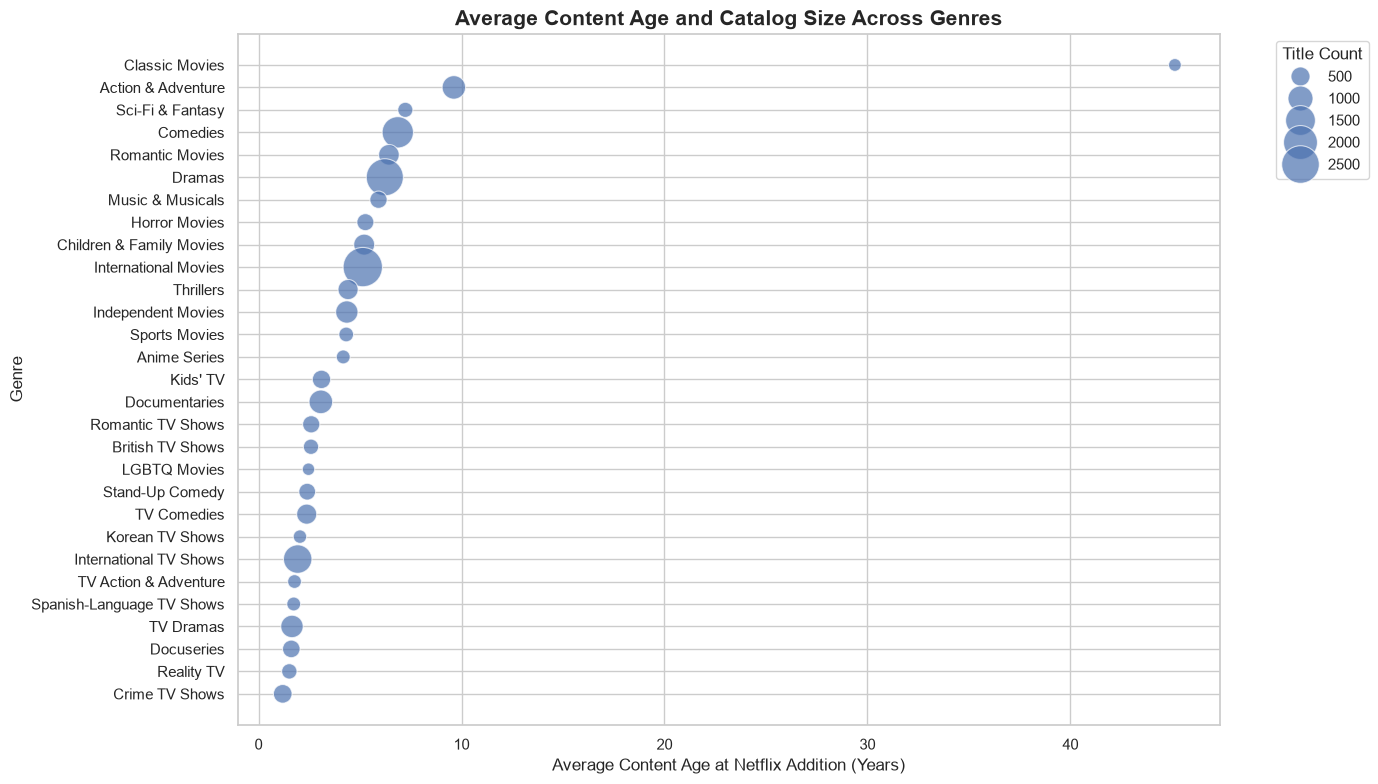

In [460]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=genre_age_filtered,
    x="average_content_age",
    y="genre",
    size="title_count",
    sizes=(80, 800),
    alpha=0.7
)

plt.title(
    "Average Content Age and Catalog Size Across Genres",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Average Content Age at Netflix Addition (Years)")
plt.ylabel("Genre")

plt.legend(
    title="Title Count",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Observation

- Classic Movies have the highest average content age at **45.15 years**, with a median of **44 years**, clearly separating them from other genre categories.
- Action & Adventure has an average content age of **9.61 years**, indicating a relatively older catalog profile compared with most major genres.
- Sci-Fi & Fantasy, Comedies, Romantic Movies, and Dramas have average content ages between approximately **6 and 7 years**.
- International Movies represent the largest analyzed genre segment with **2,752 titles** and an average content age of **5.14 years**.
- International TV Shows contain **1,350 titles** but have a much lower average content age of **1.92 years**.
- Several TV-focused genres, including TV Dramas, Docuseries, Reality TV, and Crime TV Shows, have median content ages of **0 years**.
- Crime TV Shows have the lowest average content age among the analyzed genres at approximately **1.17 years**.
- The large difference between mean and median content age in several genres indicates that older titles increase the average while the typical title remains relatively recent.

### Key Finding

Movie-oriented genres generally show higher content ages than TV-focused genres. Classic Movies form a distinct historical catalog segment, while several TV genres are strongly concentrated around recent releases.

### Business Insight

The catalog contains different freshness profiles across genres. Large Movie categories combine recent content with older catalog titles, whereas many TV genres are concentrated around titles added close to their recorded release year.

### Recommendation

Genre-level catalog evaluation should include both content age and catalog size. Large genres with higher average content age may benefit from freshness analysis, while recent TV-focused genres should be evaluated using viewer engagement and retention data before drawing acquisition conclusions.

### Analytical Note

Only genres containing at least **100 titles** were included to reduce instability from small sample averages. Titles associated with multiple genres contribute to each relevant genre category.

## 12.5 Content Addition Timing Heatmap

This analysis evaluates the interaction between month and weekday of content addition to identify temporal concentration patterns within the Netflix catalog.

In [461]:
addition_timing = pd.crosstab(
    df_clean["month_added"],
    df_clean["day_added"]
)

addition_timing = addition_timing.reindex(
    index=month_order,
    columns=day_order
)

addition_timing

day_added,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month_added,,,,,,,
January,103,103,172,63,221,32,44
February,47,51,103,87,190,49,36
March,44,81,86,174,266,44,47
April,79,84,128,113,203,87,69
May,75,108,72,87,185,75,30
June,65,70,127,140,190,109,27
July,85,100,97,161,203,78,103
August,70,109,113,145,186,64,67
September,49,100,154,103,216,74,73


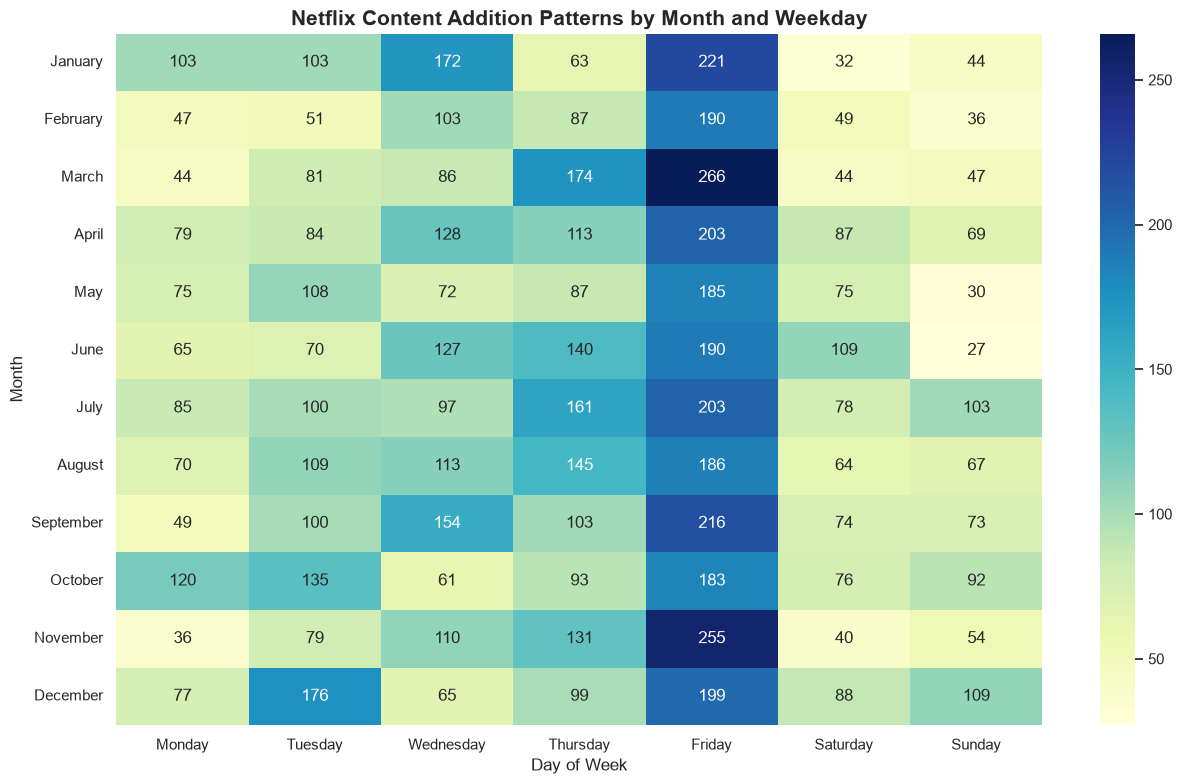

In [462]:
plt.figure(figsize=(13, 8))

sns.heatmap(
    addition_timing,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title(
    "Netflix Content Addition Patterns by Month and Weekday",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Day of Week")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

In [463]:
max_timing = addition_timing.stack().idxmax()
max_timing_count = addition_timing.stack().max()

print("Highest Addition Timing:", max_timing)
print("Number of Titles:", max_timing_count)

Highest Addition Timing: ('March', 'Friday')
Number of Titles: 266


### Observation

- Friday shows the strongest concentration of content additions across most months.
- The highest month-weekday combination is **March–Friday with 266 titles added**.
- November–Friday also shows a high concentration with **255 titles**, followed by January–Friday with **221 titles**.
- September records **216 Friday additions**, while April and July each contain **203 Friday additions**.
- December shows a comparatively different pattern, with **176 titles added on Tuesday** and **109 titles added on Sunday**.
- Thursday additions are relatively strong in March, June, July, and August.
- Weekend additions are generally lower than weekday additions, although July and December show comparatively higher Sunday activity.
- The heatmap confirms that content additions are not evenly distributed across month and weekday combinations.

### Key Finding

**March–Friday is the strongest observed content addition timing combination with 266 titles.** Friday consistently dominates catalog additions across most months.

### Business Insight

The catalog metadata shows a strong concentration of recorded content additions on Fridays. This suggests a recurring temporal addition pattern within the dataset.

### Recommendation

Friday should be treated as a key timing dimension in future catalog and engagement analysis. If viewer-level data becomes available, Friday additions should be compared with weekend watch time, title discovery, and early engagement performance.

### Analytical Note

The dataset records when titles were added to the catalog but does not explain scheduling decisions. Therefore, the Friday concentration should be interpreted as an observed catalog pattern rather than direct evidence of Netflix's internal release strategy.

# 13. Business Insights and Recommendations

This section translates the major exploratory, statistical, and multivariate findings into actionable catalog-level business insights and recommendations.

The recommendations are based on catalog metadata patterns and should be validated using viewer engagement, content cost, licensing, and revenue data before strategic implementation.

## 13.1 Content Portfolio Composition

### Business Insight

Movies dominate the Netflix catalog with **6,128 titles**, compared with **2,666 TV Shows**. Movies therefore represent approximately **69.7%** of the analyzed catalog.

Annual addition trends also show that Movies consistently received more catalog additions than TV Shows. However, the gap narrowed after 2019 as Movie additions declined more strongly.

### Recommendation

Netflix should evaluate Movie and TV Show portfolio performance separately using watch time, completion rate, acquisition cost, and subscriber retention metrics.

A larger Movie catalog does not automatically indicate stronger business performance. Content volume should be evaluated together with audience engagement and financial efficiency.

## 13.2 Geographic Content Mix

### Business Insight

The United States has the largest catalog representation across both Movies and TV Shows. However, country-level content composition differs substantially.

India is strongly Movie-oriented, while Japan and South Korea contain proportionally stronger TV Show representation. The United Kingdom shows a comparatively more balanced Movie and TV Show mix.

### Recommendation

Country-level catalog planning should use market-specific content profiles rather than a single global content mix.

Movie-focused markets and TV-focused markets should be evaluated separately using regional viewing behavior, language preferences, and subscriber engagement data.

## 13.3 Content Freshness and Catalog Age

### Business Insight

TV Shows are concentrated around more recent release years and have a median content age of **0 years**. Movies have a median content age of **2 years** and show greater historical diversity.

Genre-level analysis also shows that several TV-focused genres contain relatively recent content, while Classic Movies and some Movie genres maintain older catalog profiles.

### Recommendation

Content freshness should be evaluated at the genre and content-type level.

Older content should not automatically be treated as underperforming. Historical titles should be assessed using engagement, search demand, completion rate, and licensing cost before renewal or removal decisions.

## 13.4 Rating Portfolio Strategy

### Business Insight

TV-MA is the dominant rating for both Movies and TV Shows, representing **33.68% of Movies** and **42.95% of TV Shows**.

TV Shows also contain a comparatively larger share of children's ratings such as TV-Y and TV-Y7, while Movies have stronger representation across theatrical ratings including R, PG-13, and PG.

### Recommendation

Rating composition should be evaluated by content type and target audience segment.

Viewer demographic and household-level engagement data should be used to determine whether mature, family, and children's content categories are appropriately represented.

## 13.5 Content Addition Timing

### Business Insight

Friday is the dominant content addition day, with **2,497 titles** added on Fridays. The strongest month-weekday combination is **March–Friday with 266 titles**.

The month-weekday heatmap confirms that catalog additions are concentrated around specific temporal patterns rather than being evenly distributed.

### Recommendation

Friday additions should be compared with weekend viewing behavior, early title engagement, and content discovery metrics.

This would help determine whether concentrated Friday additions are associated with stronger short-term audience activity.

## 13.6 Runtime and TV Show Structure

### Business Insight

Movie durations are centered close to **100 minutes**, with a median of **98 minutes**. Approximately **73.42% of Movies** fall within the standard 61–120 minute duration category.

TV Shows are strongly concentrated around short-running series. The median is **1 season**, and the middle 50% of TV Shows contain between **1 and 2 seasons**.

### Recommendation

Movie runtime and TV Show season structure should be evaluated against completion rate and viewer retention.

Long-duration Movies and multi-season TV Shows should be analyzed as separate content segments because their audience consumption patterns may differ from typical catalog titles.

## 13.7 Overall Business Recommendation

Netflix catalog evaluation should move beyond title counts and use a multidimensional performance framework.

The analysis indicates meaningful differences across content type, country, genre, rating, content age, runtime, and addition timing.

Future catalog decisions should integrate:

- Viewer watch time and completion rate
- Subscriber retention and acquisition impact
- Content licensing and production cost
- Regional and language-level demand
- Genre and rating-level engagement
- Content age and catalog freshness
- Release timing and early engagement performance

A combined catalog and viewer-performance framework would provide stronger evidence for content acquisition, renewal, licensing, and portfolio optimization decisions.

# 14. Executive KPI Summary

This section consolidates the most important catalog metrics identified throughout the analysis into a single executive-level KPI table.

In [464]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Titles",
        "Total Movies",
        "Total TV Shows",
        "Movie Catalog Share",
        "TV Show Catalog Share",
        "Top Content Country",
        "Top Genre",
        "Dominant Rating",
        "Average Movie Duration",
        "Median Movie Duration",
        "Average TV Show Seasons",
        "Median TV Show Seasons",
        "Median Release Year",
        "Median Content Age",
        "Peak Addition Year",
        "Peak Addition Month",
        "Peak Addition Weekday",
        "Top Month-Weekday Combination"
    ],
    "Value": [
        f"{len(df_clean):,}",
        f"{(df_clean['type'] == 'Movie').sum():,}",
        f"{(df_clean['type'] == 'TV Show').sum():,}",
        f"{(df_clean['type'] == 'Movie').mean() * 100:.2f}%",
        f"{(df_clean['type'] == 'TV Show').mean() * 100:.2f}%",
        country_type_data["country"].value_counts().idxmax(),
        genre_age_data["genre"].value_counts().idxmax(),
        df_clean["rating"].mode()[0],
        f"{movies['duration_value'].mean():.2f} Minutes",
        f"{movies['duration_value'].median():.0f} Minutes",
        f"{tv_shows['duration_value'].mean():.2f} Seasons",
        f"{tv_shows['duration_value'].median():.0f} Season",
        f"{df_clean['release_year'].median():.0f}",
        (
            f"{df_clean['content_age'].median():.0f} Year"
            if df_clean["content_age"].median() == 1
            else f"{df_clean['content_age'].median():.0f} Years"
        ),
        str(df_clean["year_added"].value_counts().idxmax()),
        df_clean["month_added"].value_counts().idxmax(),
        df_clean["day_added"].value_counts().idxmax(),
        f"{max_timing[0]} - {max_timing[1]} ({max_timing_count} Titles)"
    ]
})

executive_kpis

,KPI,Value
0,Total Titles,"8,794"
1,Total Movies,"6,128"
2,Total TV Shows,"2,666"
3,Movie Catalog Share,69.68%
4,TV Show Catalog Share,30.32%
5,Top Content Country,United States
6,Top Genre,International Movies
7,Dominant Rating,TV-MA
8,Average Movie Duration,99.58 Minutes
9,Median Movie Duration,98 Minutes


In [465]:
executive_kpis.style \
    .hide(axis="index") \
    .set_caption("Netflix Catalog Executive KPI Summary") \
    .set_properties(**{
        "text-align": "left"
    })

KPI,Value
Total Titles,"8,794"
Total Movies,"6,128"
Total TV Shows,"2,666"
Movie Catalog Share,69.68%
TV Show Catalog Share,30.32%
Top Content Country,United States
Top Genre,International Movies
Dominant Rating,TV-MA
Average Movie Duration,99.58 Minutes
Median Movie Duration,98 Minutes


### Executive KPI Interpretation

- The analyzed Netflix catalog contains **8,794 titles**, including **6,128 Movies** and **2,666 TV Shows**.
- Movies represent **69.68%** of the catalog, confirming a Movie-dominant portfolio.
- The **United States** has the highest content representation.
- **International Movies** is the largest genre category.
- **TV-MA** is the dominant content rating.
- Movies have an average duration of **99.58 minutes** and a median duration of **98 minutes**.
- TV Shows have an average of **1.75 seasons**, with a median of **1 season**.
- The median release year is **2017**, showing that the catalog is concentrated around relatively recent content.
- The median content age is **1 year**, indicating that a typical title was added close to its recorded release year.
- **2019** recorded the highest number of content additions.
- **July** is the leading addition month, while **Friday** is the dominant addition weekday.
- **March–Friday** is the strongest month-weekday combination, with **266 titles**.

### Executive KPI Conclusion

The KPI summary shows a Movie-dominant catalog with strong international representation, mature-audience content concentration, relatively recent titles, and a clear Friday-focused addition pattern.

These KPIs provide a concise executive overview and create a strong foundation for dashboard development and business reporting.

# 15. Executive Summary

This project analyzed **8,794 Netflix catalog titles** to identify patterns across content type, geographic representation, genre, rating, release timing, content age, Movie duration, and TV Show season structure.

## Catalog Overview

The Netflix catalog is strongly Movie-dominant, containing **6,128 Movies (69.68%)** and **2,666 TV Shows (30.32%)**. The **United States** has the largest catalog representation, while **International Movies** is the most represented genre category.

## Content Structure

Movie durations are centered around approximately **100 minutes**, with an average duration of **99.58 minutes** and a median of **98 minutes**. Approximately **73.42% of Movies** fall within the standard **61–120 minute** duration range.

TV Shows are concentrated around shorter series structures. The average TV Show contains **1.75 seasons**, while the median is **1 season**. The middle 50% of TV Shows contain between **1 and 2 seasons**.

## Catalog Freshness

The median release year is **2017**, indicating that the catalog is concentrated around relatively recent titles. The median content age is **1 year**, suggesting that a typical title was added relatively close to its recorded release year.

TV Shows are generally more recent than Movies. TV Shows have a median content age of **0 years**, compared with **2 years for Movies**. Movies, however, provide greater historical catalog diversity.

## Geographic and Genre Patterns

Content composition differs substantially across countries. The United States dominates both Movies and TV Shows, India is strongly Movie-oriented, while Japan and South Korea show greater TV Show representation.

Genre-level analysis identified different catalog freshness profiles. **Classic Movies** have the highest average content age at **45.15 years**, while several TV-focused genres are concentrated around recent content additions.

## Rating Composition

**TV-MA** is the dominant rating for both Movies and TV Shows, representing **33.68% of Movies** and **42.95% of TV Shows**.

TV Shows contain a comparatively larger share of children's ratings, while Movies show greater representation across theatrical rating categories such as R, PG-13, and PG.

## Content Addition Patterns

Netflix catalog additions reached their highest observed level in **2019**. **July** recorded the highest monthly additions, while **Friday** is the dominant addition weekday with **2,497 titles**.

The strongest month-weekday combination is **March–Friday**, with **266 titles added**.

## Statistical Findings

Movie duration shows an approximately symmetric distribution with moderate relative variability. TV Show season counts are highly positively skewed because most series contain few seasons while a smaller number of long-running shows extend the distribution.

Outlier analysis identified unusual observations across release years, Movie durations, and TV Show season counts. These values were retained because statistical outliers may represent valid catalog segments rather than data quality errors.

Independent numerical variables showed only weak linear correlations. The engineered `content_age` variable was excluded from independent correlation analysis because it is mathematically derived from release year and year added.

## Business Recommendations

Netflix catalog evaluation should use separate analytical frameworks for Movies and TV Shows because their duration, lifecycle, freshness, and geographic composition differ substantially.

Country and genre-level catalog profiles should be evaluated using regional viewer behavior, watch time, completion rate, and subscriber retention metrics.

Friday content additions should be compared with weekend engagement patterns to determine whether timing concentration is associated with stronger early title performance.

Older and statistically unusual titles should not be automatically removed from catalog analysis. Their performance should be evaluated using engagement, licensing cost, search demand, and retention contribution.

## Final Conclusion

The analysis demonstrates that the Netflix catalog contains distinct structural patterns across content type, country, genre, rating, content age, runtime, and addition timing.

The catalog is Movie-dominant, concentrated around relatively recent content, and shows a strong Friday-focused addition pattern. Movies provide broader historical diversity, while TV Shows are more concentrated around recent and short-running content.

Integrating catalog metadata with viewer engagement, financial, and regional demand data would enable stronger evidence-based decisions for content acquisition, licensing, renewal, and portfolio optimization.

## Analytical Limitation

This project analyzes catalog metadata only. The dataset does not include viewer watch time, completion rate, subscriber behavior, content cost, licensing information, or revenue. Therefore, the findings describe catalog structure and patterns but do not directly measure content performance or profitability.